# Análisis de las series de tiempo a utilizar

A continuación se llevarán a cabo los distintos pasos para analizar las series de tiempo asociadas al trabajo de título. El presente archivo se refiere al análisis EDA del dataset pollution (BD1)

# Importaciones





Se inicia llevando a cabo las importaciones necesarias

In [ ]:
pip install adtk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller
import pandas as pd
import seaborn as sns
from google.colab import drive
import plotly.express as px
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats


# Se lee la base de datos

In [ ]:
#drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Tesis/Data/pollutionOriginal.csv')

En una primera etapa, se busca comprender el dataframe, en específico sus características. Para lograr esto se imprime la forma de la base de datos (filas, columnas), el nombre de las columnas, y a modo de prueba, se imprimen las primeras  5 observaciones que la conforman.

In [ ]:
#Se imprime la forma
print(df.shape)

#Se imprime el nombre de las columnas
print(df.columns)

#Se imprimen las primeras 5 observaciones
print(df.head())


(43824, 13)
Index(['No', 'year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES',
       'cbwd', 'Iws', 'Is', 'Ir'],
      dtype='object')
   No  year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd    Iws  Is  Ir
0   1  2010      1    1     0    NaN   -21 -11.0  1021.0   NW   1.79   0   0
1   2  2010      1    1     1    NaN   -21 -12.0  1020.0   NW   4.92   0   0
2   3  2010      1    1     2    NaN   -21 -11.0  1019.0   NW   6.71   0   0
3   4  2010      1    1     3    NaN   -21 -14.0  1019.0   NW   9.84   0   0
4   5  2010      1    1     4    NaN   -20 -12.0  1018.0   NW  12.97   0   0


Desde este punto, se puede concluir que la base de datos cuenta con 43.824 filas y 13 columnas. Estas últimas incluyen los datos de tiempo (year, month, day, hour) separadas individualmente.


---



Los nombres no terminan siendo lo suficientemente representativos y no cumplen un estandar establecido.



---


Las primeras filas permiten ver la presencia de datos faltantes.




Siendo una serie de tiempo, se incluirá la fecha y hora de la observación como el index del dataframe

In [ ]:
# Se combinan columnas
df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Se establece la columna date como index
df.set_index('date', inplace=True)

# Se eliminan las columnas originales junto con No, puesto que se tiene un nuevo index
df.drop(['year', 'month', 'day', 'hour', 'No'], axis=1, inplace=True)

# Se muestra el dataframe resultante
print(df)

                     pm2.5  DEWP  TEMP    PRES cbwd     Iws  Is  Ir
date                                                               
2010-01-01 00:00:00    NaN   -21 -11.0  1021.0   NW    1.79   0   0
2010-01-01 01:00:00    NaN   -21 -12.0  1020.0   NW    4.92   0   0
2010-01-01 02:00:00    NaN   -21 -11.0  1019.0   NW    6.71   0   0
2010-01-01 03:00:00    NaN   -21 -14.0  1019.0   NW    9.84   0   0
2010-01-01 04:00:00    NaN   -20 -12.0  1018.0   NW   12.97   0   0
...                    ...   ...   ...     ...  ...     ...  ..  ..
2014-12-31 19:00:00    8.0   -23  -2.0  1034.0   NW  231.97   0   0
2014-12-31 20:00:00   10.0   -22  -3.0  1034.0   NW  237.78   0   0
2014-12-31 21:00:00   10.0   -22  -3.0  1034.0   NW  242.70   0   0
2014-12-31 22:00:00    8.0   -22  -4.0  1034.0   NW  246.72   0   0
2014-12-31 23:00:00   12.0   -21  -3.0  1034.0   NW  249.85   0   0

[43824 rows x 8 columns]


A modo de que sean más comprensibles y sigan un estándar predeterminado (abreviaciones en minúsculas), se modifica el nombre de las columnas

In [ ]:
names = ['pollution', 'dew', 'temp', 'press', 'wnd_dir', 'wnd_spd', 'snow', 'rain']
df.columns = names
print(df)

                     pollution  dew  temp   press wnd_dir  wnd_spd  snow  rain
date                                                                          
2010-01-01 00:00:00        NaN  -21 -11.0  1021.0      NW     1.79     0     0
2010-01-01 01:00:00        NaN  -21 -12.0  1020.0      NW     4.92     0     0
2010-01-01 02:00:00        NaN  -21 -11.0  1019.0      NW     6.71     0     0
2010-01-01 03:00:00        NaN  -21 -14.0  1019.0      NW     9.84     0     0
2010-01-01 04:00:00        NaN  -20 -12.0  1018.0      NW    12.97     0     0
...                        ...  ...   ...     ...     ...      ...   ...   ...
2014-12-31 19:00:00        8.0  -23  -2.0  1034.0      NW   231.97     0     0
2014-12-31 20:00:00       10.0  -22  -3.0  1034.0      NW   237.78     0     0
2014-12-31 21:00:00       10.0  -22  -3.0  1034.0      NW   242.70     0     0
2014-12-31 22:00:00        8.0  -22  -4.0  1034.0      NW   246.72     0     0
2014-12-31 23:00:00       12.0  -21  -3.0  1034.0   

Se revisa el tipo de datos de las variables

In [ ]:
#Se imprime el tipo de dato
print(df.dtypes)
#Se verifica que el index está en formato de dato "datetime64"
print("El index del dataframe es un tipo de dato: ",df.index.dtype)

pollution    float64
dew            int64
temp         float64
press        float64
wnd_dir       object
wnd_spd      float64
snow           int64
rain           int64
dtype: object
El index del dataframe es un tipo de dato:  datetime64[ns]


Todos los datos son numéricos, a excepción de wnd_dir (dirección del viento), que es un tipo de dato object. Hay que recordar que esta variable es categórica.

# Análisis EDA

## Aumento de dimensionalidad

No existen motivos directos por los cuales sea necesario aplicar un método de aumento de dimensionalidad sobre el dataset.

## Reconocimiento


Se procede a analizar diferentes métricas estadísticas de la base de datos

In [ ]:
df.describe()

,pollution,dew,temp,press,wnd_spd,snow,rain
count,41757.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,98.613215,1.817246,12.448521,1016.447654,23.889140,0.052734,0.194916
std,92.050387,14.433440,12.198613,10.268698,50.010635,0.760375,1.415867
min,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000
25%,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000
50%,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000
75%,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000
max,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000


De la tabla anterior se puede apreciar que:



1.   El conteo de elementos de la columna pollution es el único distinto, siendo este de 41.757, a diferencia del resto que es de 43.824, al igual que el número de columnas. Esto da a entender que muy probablemente la columna pollution posea datos faltantes. Esto se estudiará en mayor profundidad en la sección siguiente.
2.   Los valores de mean y std entre las diferentes columnas cambian considerablemente, dando cuenta así de la diferentes escalas que se manejan dentro del dataset original.
1.   El 75% de pollution y wnd_spd están claramente alejados del valor máximo observado, llevando a la posibilidad de que existan outliers en estas variables. De igual manera, estas son las variables que notablemente poseen un 50% superior al valor de la media, aumentando así la creencia de la aparición de outliers.
1.   La mayoría de las observaciones de snow y rain son de 0.





Se imprimen los gráficos

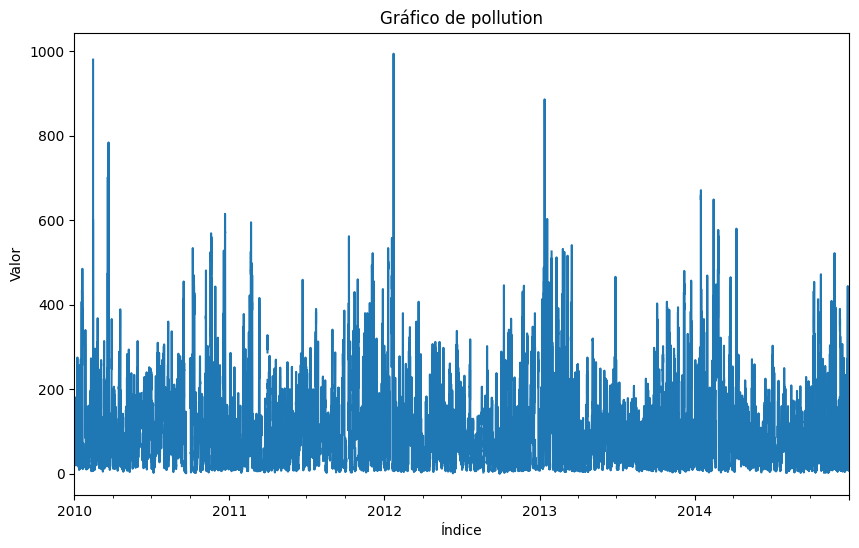

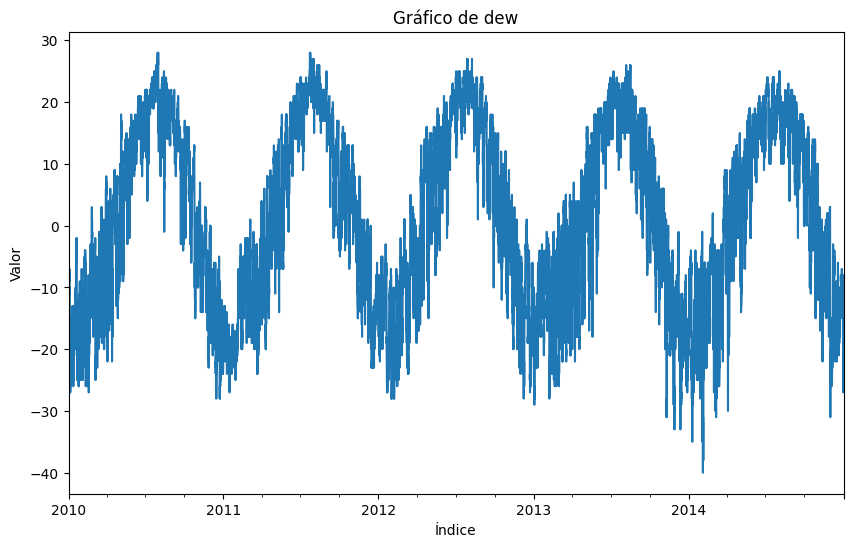

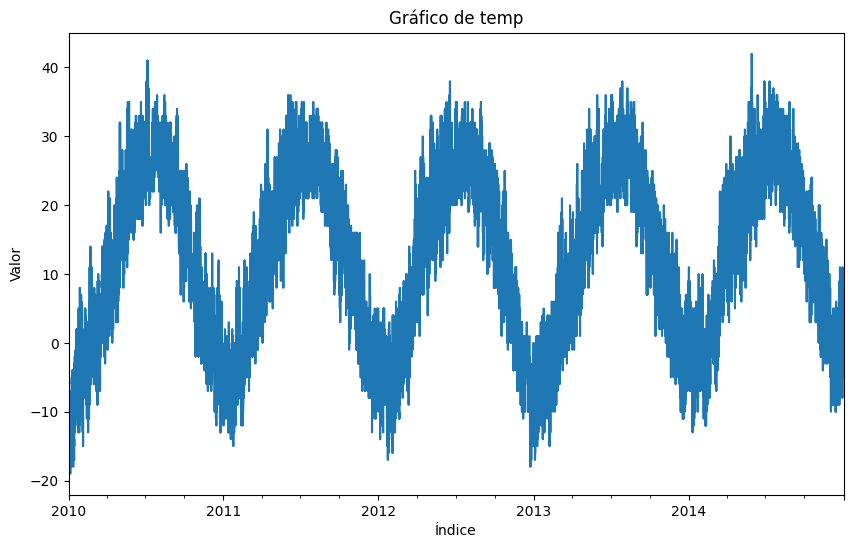

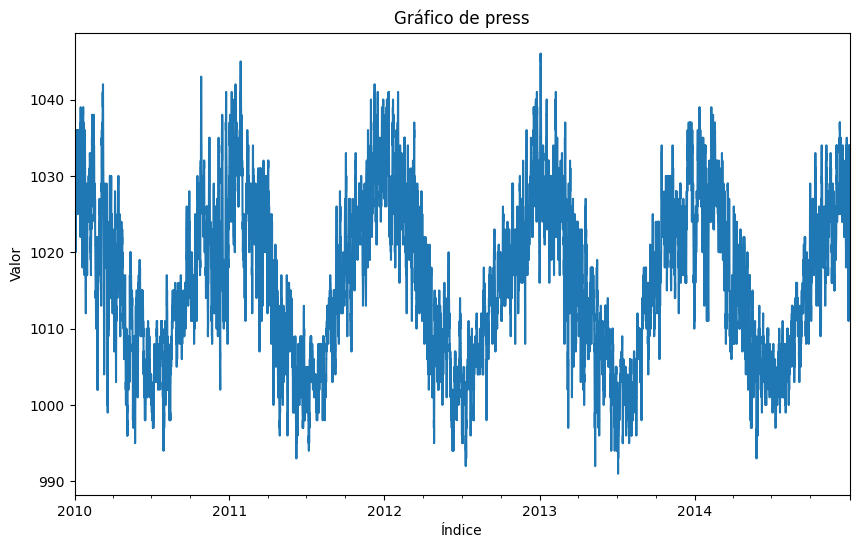

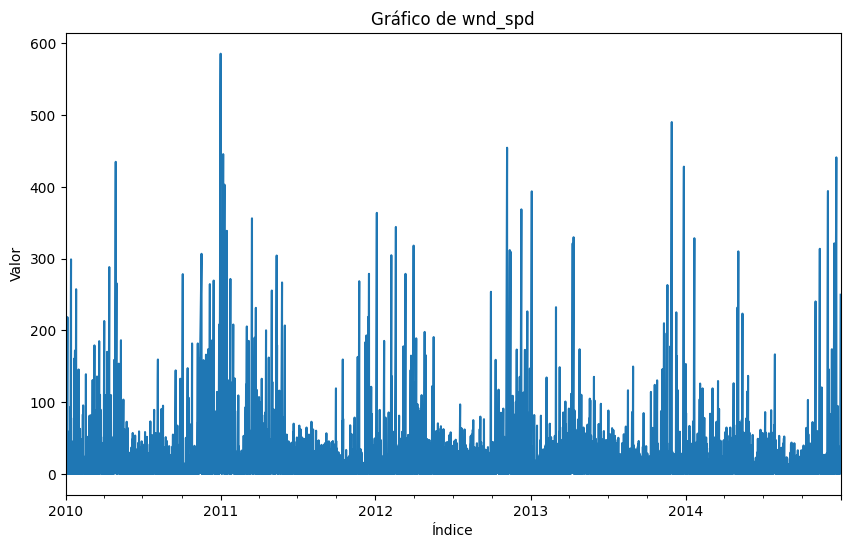

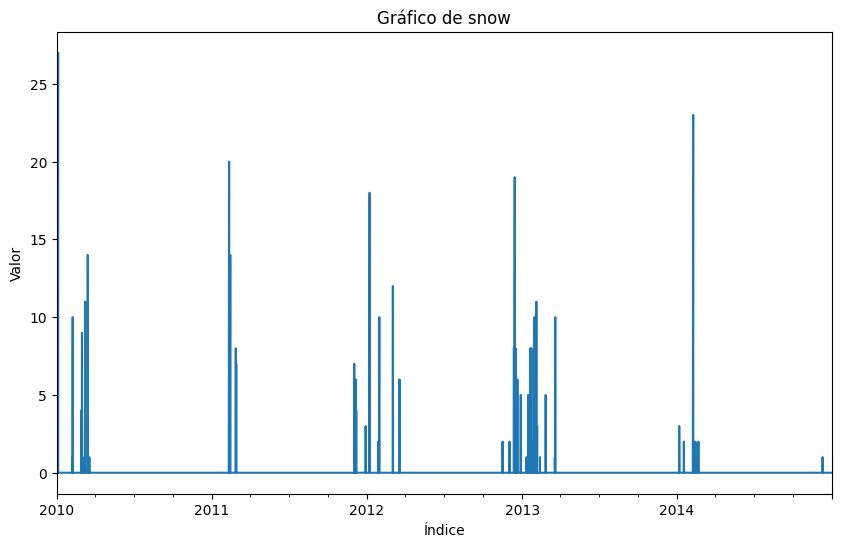

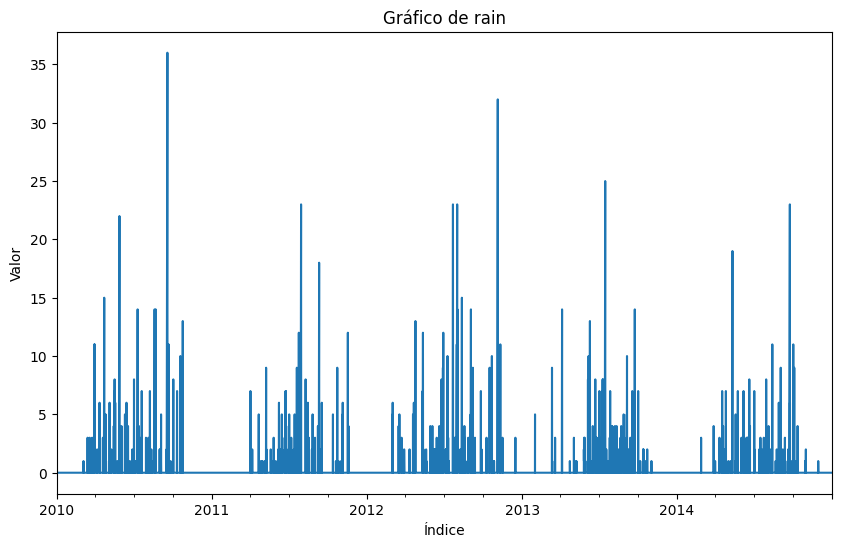

In [ ]:
# Iteramos sobre cada columna y trazamos un gráfico para cada una
for col in df.columns:
    if col != "wnd_dir":
      plt.figure(figsize=(10, 6))  # Tamaño del gráfico
      df[col].plot()
      plt.title('Gráfico de {}'.format(col))
      plt.xlabel('Índice')  
      plt.ylabel('Valor')    
      plt.show()


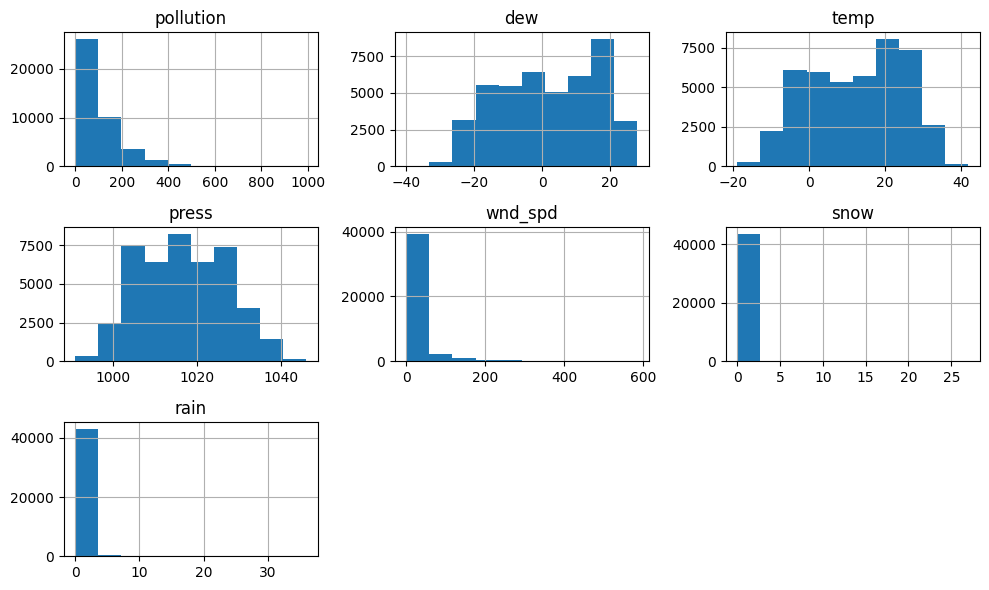

In [ ]:
# Trazar un histograma para cada variable en el DataFrame
df.hist(figsize=(10, 6))

# Mostrar los histogramas
plt.tight_layout()
plt.show()

Al ser originalmente categórica, se prefiere representar a la distribución de la variable "wnd_dir" por medio de un gráfico de barras. En este, se puede observar que se registró con mayor frecuencia la varaible SE, seguida por NW, CV y finalmente NE. Por otro lado, nunca se registró una dirección de viento con valor SW, hecho que no pareciese ser representativo de la realidad. Sin embargo de acuerdo al documento original en donde se presenta la base de datos utilizada para llevar a cavo los análisis se usan 4 medidas de dirección de viento: NW, NE, S y CV, teniendo a S como representación tanto de SW como de SE, medida que se toma puesto que se plantea la existencia de una fuerte correlación entre los vientos provenientes del sur y el aumento de los niveles de polución. Por ende, siendo el valor más representativo, y siguiendo la lógica del documento, se cree que por un error humano se renombró a la variable S como SE.

<Axes: xlabel='wnd_dir'>

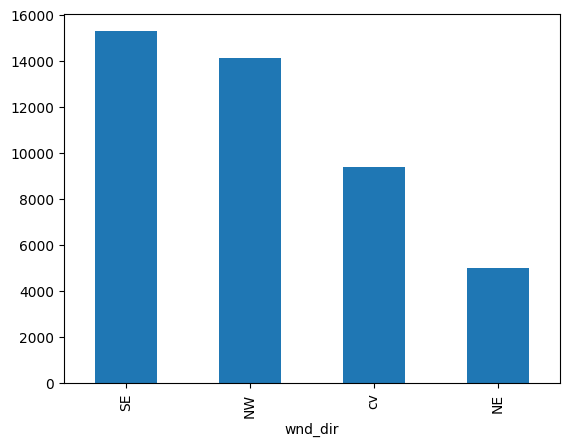

In [ ]:
df['wnd_dir'].value_counts().plot(kind="bar")

In [ ]:

fig = px.line(df, x=df.index, y='pollution', title='Pollution graph')
fig.update_xaxes(rangeslider_visible=True,
                 rangeselector=dict(
                     buttons=list([
                         dict(count=1, label='1y', step="year", stepmode="backward"),
                         dict(count=2, label='2y', step="year", stepmode="backward"),
                         dict(count=3, label='3y', step="year", stepmode="backward"),
                         dict(step="all")
                     ])
                 )
)
fig.show()




/usr/local/lib/python3.10/dist-packages/_plotly_utils/basevalidators.py:105: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  v = v.dt.to_pydatetime()


Pasando al análisis de la serie a predecir, esta se grafica separando cada año por colores. De esta se puede ver que pareciese haber estacionalidad puesto que al inicio y al final de los años los niveles de la variable pollution aumentan considerablemente, pero a mediados de año aparece un decaimiento notable.

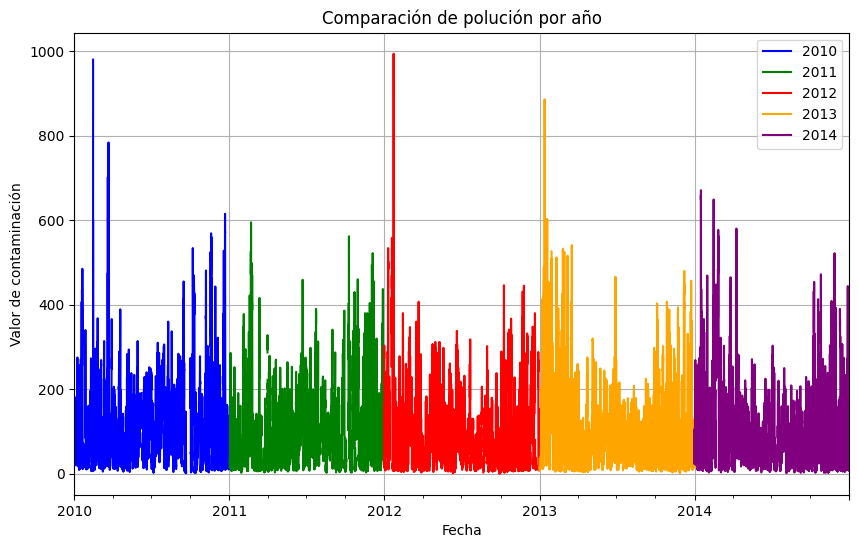

In [ ]:

# Series de tiempo en un solo gráfico
plt.figure(figsize=(10, 6))

# Se separan las series por año
df.loc["2010"]["pollution"].plot(label='2010', color='blue')
df.loc["2011"]["pollution"].plot(label='2011', color='green')
df.loc["2012"]["pollution"].plot(label='2012', color='red')
df.loc["2013"]["pollution"].plot(label='2013', color='orange')
df.loc["2014"]["pollution"].plot(label='2014', color='purple')

# Se añaden títulos
plt.title('Comparación de polución por año')
plt.xlabel('Fecha')
plt.ylabel('Valor de contaminación')
plt.legend()
plt.grid(True)
plt.show()

Se estudia la correlación entre las variables. En primera instancia mediante gráficos scatterplot. En estos es posible ver una correlación negativa fuerte entre:

*   pollution y wnd_spd
*   dew y press
*   press y temp

Por otro lado, las variables que pareciesen presentar correlaciones positivas fuertes son:

*   dew y temp
*   dew y hum



Para confirmar lo anterior, se utiliza un gráfico HeatMap en donde se marca el valor de las correlaciones encontradas. A partir de este se pueden confirmar las conjeturas realizadas en base a los gráficos scatterplot, a excepción de la correlación fuerte entre pollution y wnd_spd, que si bien existe, no es considerablemente fuerte.







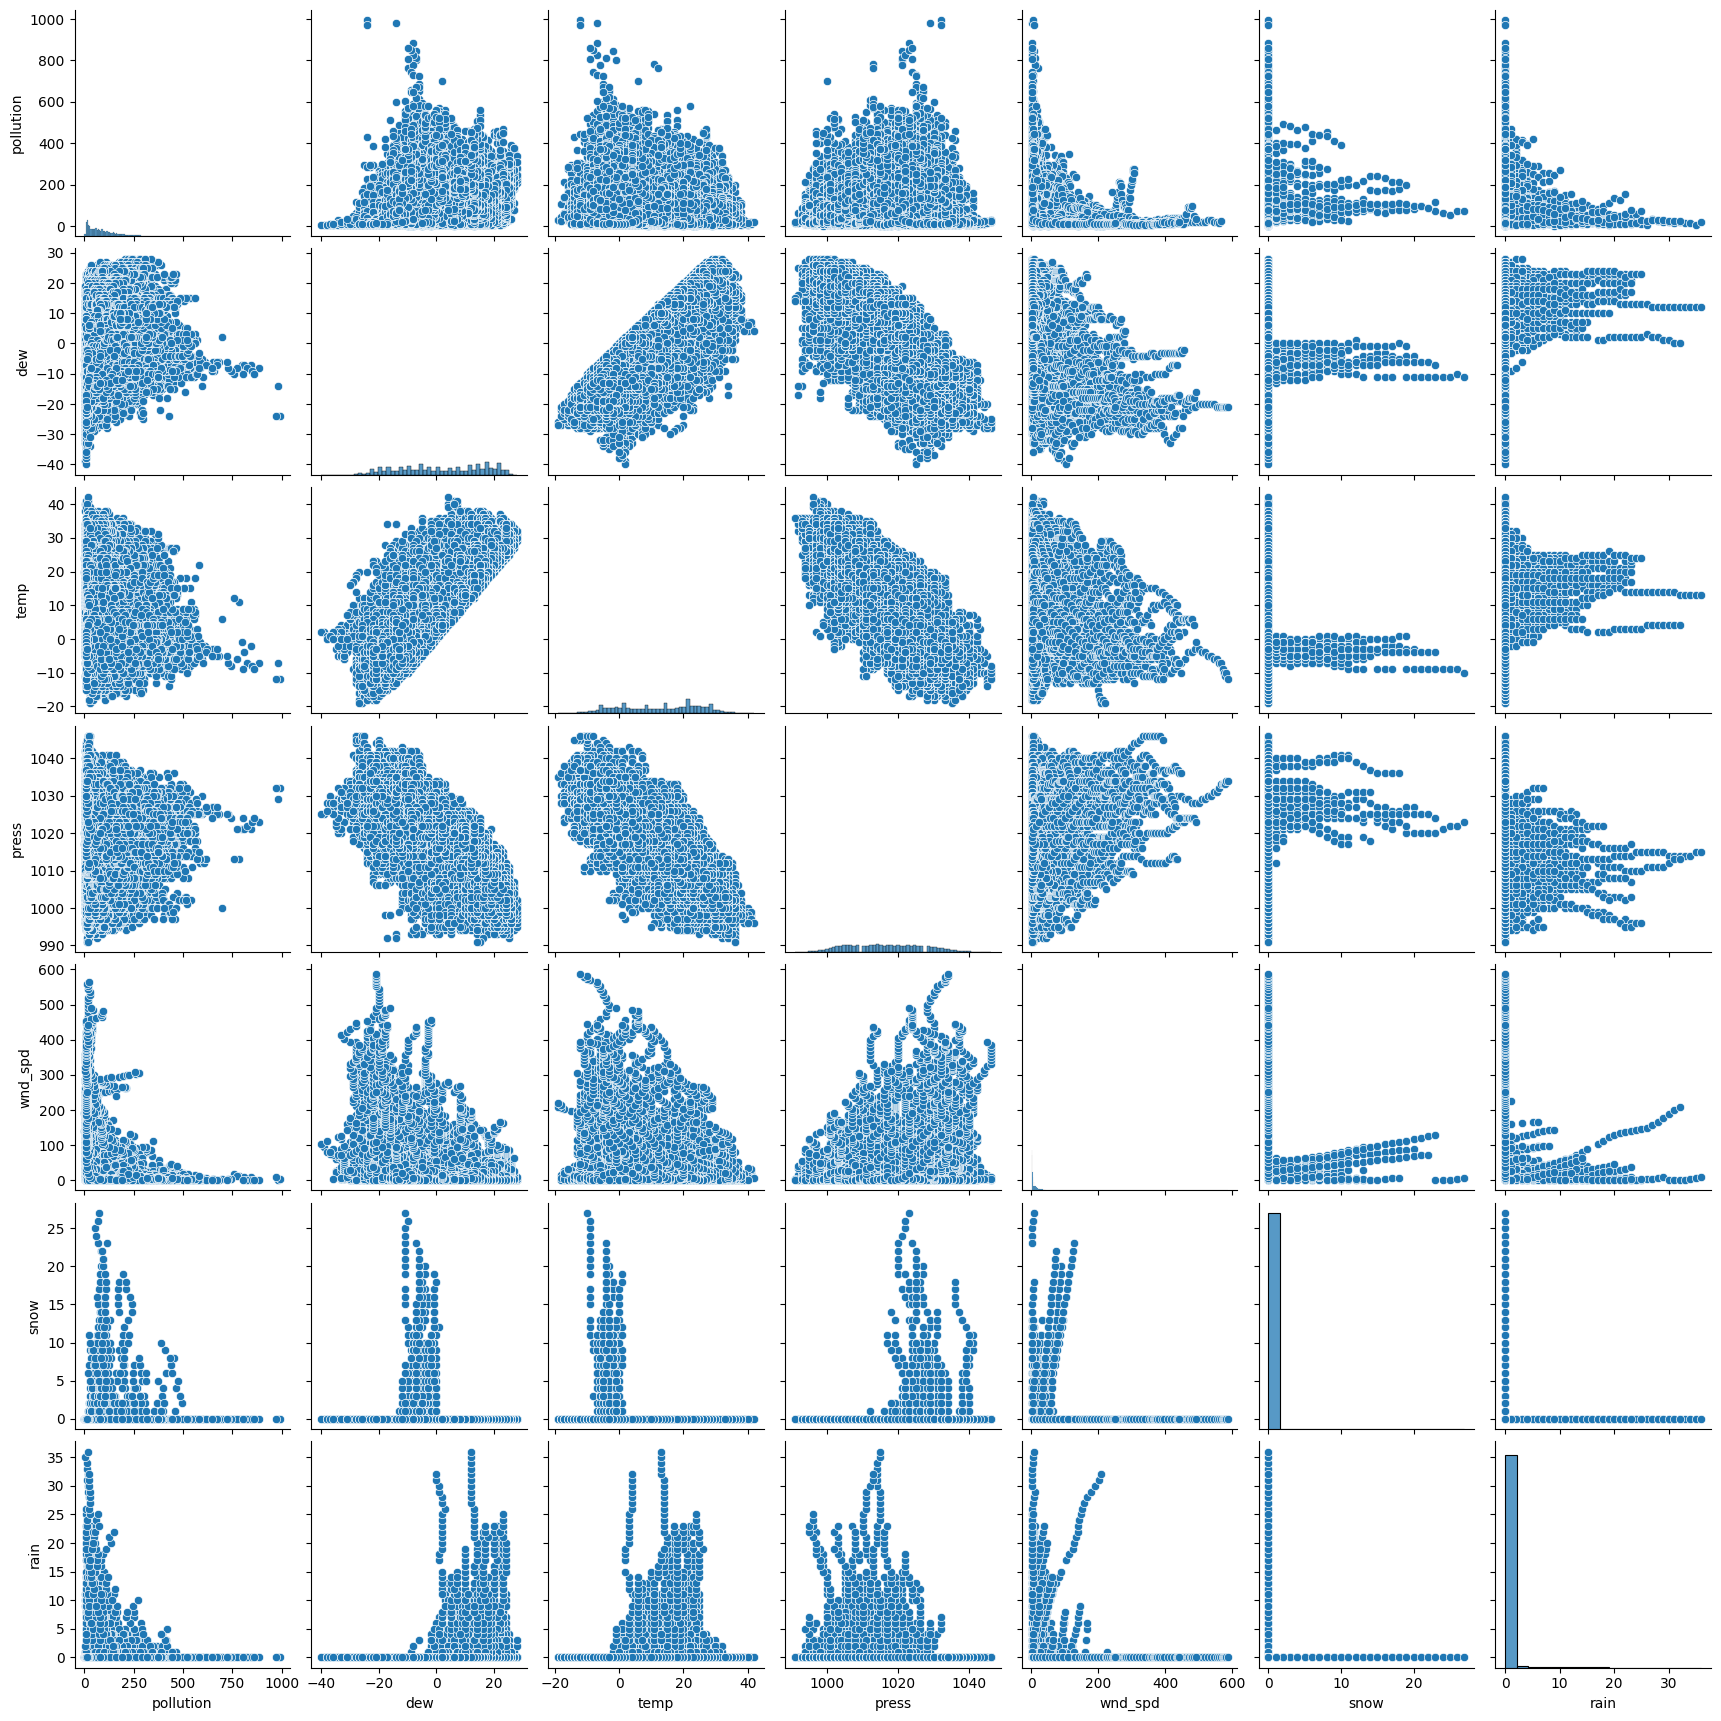

In [ ]:
sns.pairplot(df)
plt.show()

<Axes: >

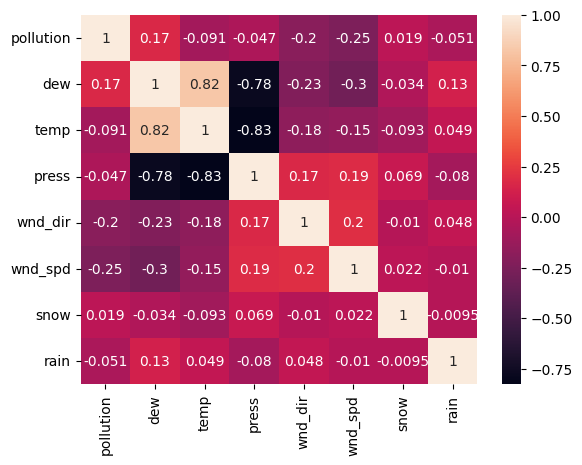

In [ ]:
df_corr= df.corr()
sns.heatmap(df_corr, annot=True)

<Axes: >

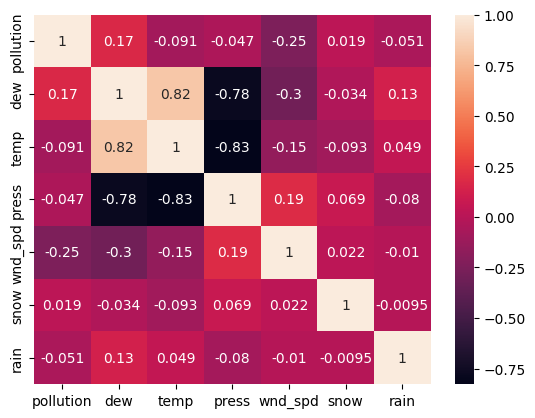

In [ ]:
df_corr = df.drop(["wnd_dir"], axis=1)
df_corr= df_corr.corr()
sns.heatmap(df_corr, annot=True)

Como se puede observar en el grafo anterior

## Discretización y numeración

Se pasa variable categórica a numérica, entero

In [ ]:
mapeo = {"cv": 0, "SE": 1, "NW": 2, "NE": 3}
df['wnd_dir'] = df['wnd_dir'].map(mapeo)

#Se comprueba cambio
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43824 entries, 2010-01-01 00:00:00 to 2014-12-31 23:00:00
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pollution  41757 non-null  float64
 1   dew        43824 non-null  int64  
 2   temp       43824 non-null  float64
 3   press      43824 non-null  float64
 4   wnd_dir    43824 non-null  int64  
 5   wnd_spd    43824 non-null  float64
 6   snow       43824 non-null  int64  
 7   rain       43824 non-null  int64  
dtypes: float64(4), int64(4)
memory usage: 3.0 MB


## Valores faltantes

Se revisa la presencia de valores NaN

In [ ]:
df.isna().sum()


,0
pollution,2067
dew,0
temp,0
press,0
wnd_dir,0
wnd_spd,0
snow,0
rain,0


Confirmando lo visto anteriormente en la tabla de estadísticas, la variable pollution es la única que mantiene valores nulos. Se procede a medir la proporción de dichos valores.

In [ ]:
# Total de NaN en el dataframe
total_nan = df.isna().sum().sum()

# Total de datos
total_datos = df.shape[0]

# Proporción
prop_nan = (total_nan / total_datos) * 100

print(f"Porcentaje de valores NaN en relación al total de datos: {prop_nan:.2f}%")

Porcentaje de valores NaN en relación al total de datos: 4.72%


La cantidad de datos faltantes en de 4,72%. Se cree que es apropiado estudiar estos datos, para así tener un mayor entendimiento de los datos en general.

Se inicia por relacionar los datos faltantes de pollution con el resto de variables a través de un heatmap de la librería sns.






<Axes: ylabel='date'>

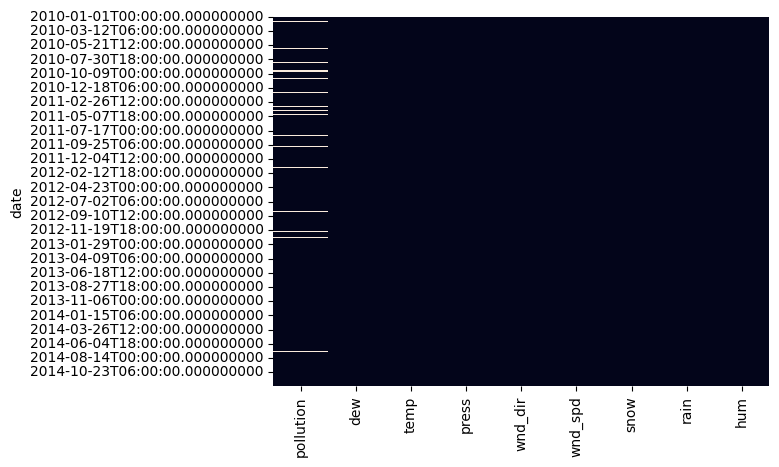

In [ ]:
sns.heatmap(df.isnull(), cbar=False)

No parece haber un patrón marcado de los valores faltantes (líneas blancas), más allá que disminuye su presencia a lo largo del año 2013. Como el resto de las variables no poseen valores NaN, el mapa de calor no entrega más información.

Ahora bien, se estudia la presencia de patrones en distintas escalas de tiempo con histogramas.

**Horas**: Se buscan patrones de concentración a lo largo de las diferente horas del día.

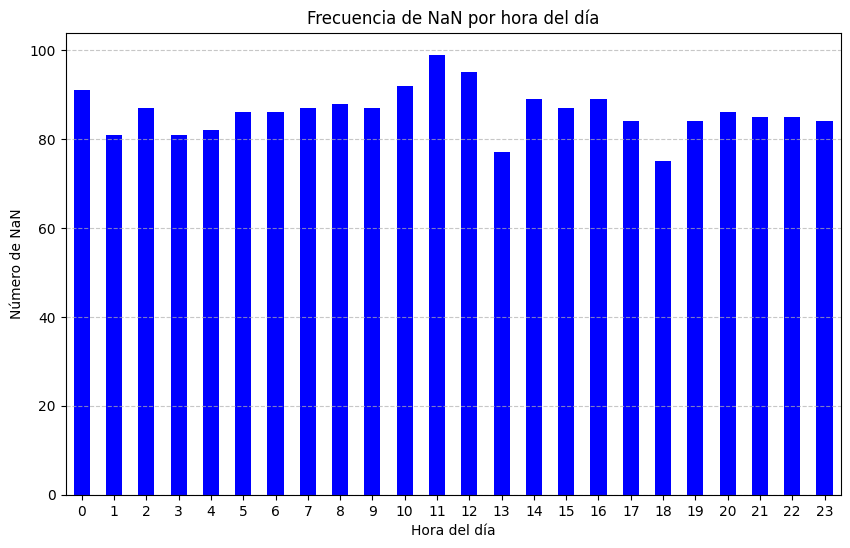

In [ ]:
# Se agrupan datos por hora
faltantes_hora = df.groupby(df.index.hour)['pollution'].apply(lambda x: x.isnull().sum())

# Se imprime el gráfico
plt.figure(figsize=(10, 6))
faltantes_hora.plot(kind='bar', color='blue')
plt.title('Frecuencia de NaN por hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Número de NaN')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Día**: Se buscan patrones en un periodo de 30 días (1 mes)

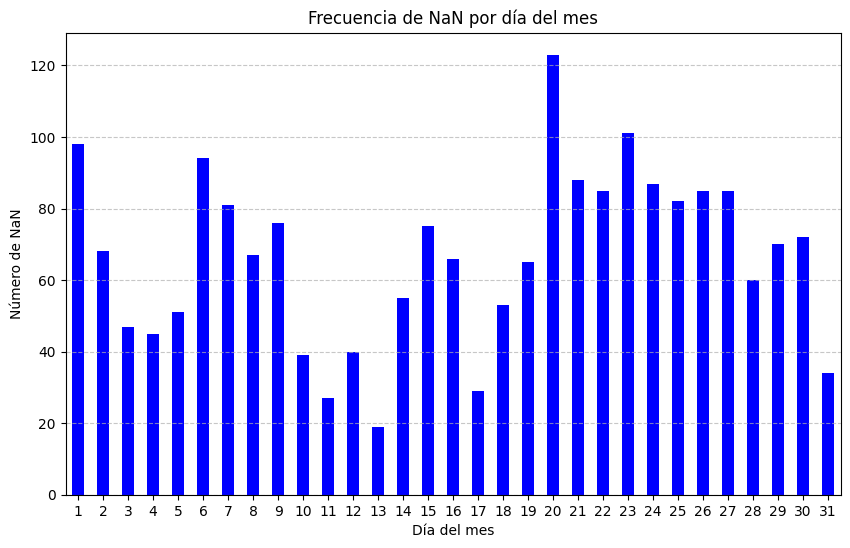

In [ ]:
# Se agrupan datos por dia
faltantes_dia = df.groupby(df.index.day)['pollution'].apply(lambda x: x.isnull().sum())

# Se imprime el gráfico
plt.figure(figsize=(10, 6))
faltantes_dia.plot(kind='bar', color='blue')
plt.title('Frecuencia de NaN por día del mes')
plt.xlabel('Día del mes')
plt.ylabel('Número de NaN')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Mes**: Se buscan patrones en los 12 meses del año

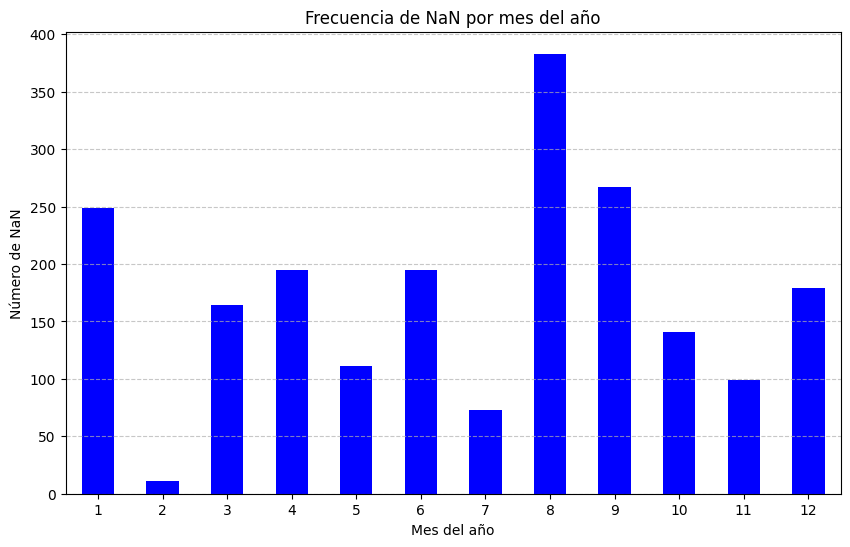

In [ ]:
# Se agrupan datos por mes
faltantes_mes = df.groupby(df.index.month)['pollution'].apply(lambda x: x.isnull().sum())

# Se imprime el gráfico
plt.figure(figsize=(10, 6))
faltantes_mes.plot(kind='bar', color='blue')
plt.title('Frecuencia de NaN por mes del año')
plt.xlabel('Mes del año')
plt.ylabel('Número de NaN')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Del gráfico relacionado a las horas del día, no pareciese haber algún tipo de patrón, siendo los resultados bastante similares entre sí, mostrándose una tendencia hacia los 80 NaNs. Es así como no pareciese existir una predisposición por algún momento del día en particular para que no se registren datos (día o noche, tarde o mañana, etc.). Esto se diferencia del gráfico asociado a los días del mes, en donde se muestra una disminución de la cantidad de datos faltantes aproximadamente a mediados del mes.

Luego, del gráfico de meses, la perdida de datos se concentra en el mes 8 (agosto), mientras que los meses con menos pérdida de datos son 2 (febrero) y 7(julio). A pesar de esto, no pareciese haber algún patrón claro que haga pensar que el mes de la observación tenga alguna relevancia especial con respecto a la presencia de errores. Dentro del paper original que presenta los datos no se explica si la pérdida pueda deberse a algún suceso particular. De igual forma, estos meses no coinciden con días festivos en China que pudiesen significar alguna falta humana más allá del año nuevo Chino, pero este en su mayoría cayó en febrero o fechas cercanas a febrero durante estos años, lo cual no coincide con los resultados obtenidos https://www.china-health-insurance.com/es/resources/china-information/chinese-holidays-and-celebrations/.   

Para analizar los datos en términos del año, se grafica el histograma tomando en cuenta la distribución de NaNs en el mes de cada año. Del gráfico se observa que en los primeros años se presenció una mayor pérdida de datos, seguida por una caída sustancial en los años 2013 y 2014. Esto puede deberse a un mejoramiento en las metodologías para la toma de observaciones.

<Figure size 1200x600 with 0 Axes>

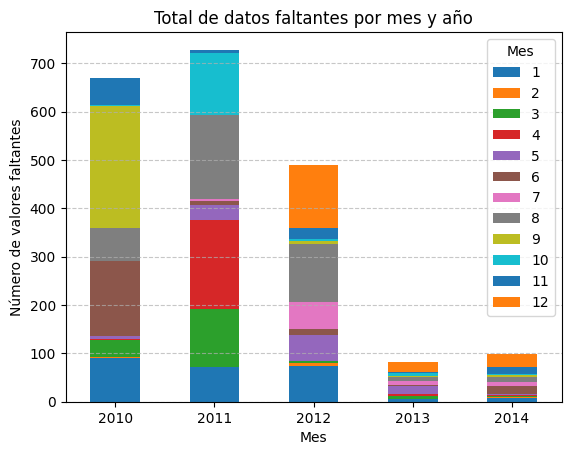

In [ ]:

# Se agrupan datos en años y meses
faltantes_mes_año = df.groupby([df.index.year, df.index.month])['pollution'].apply(lambda x: x.isnull().sum()).unstack()
# Se muestra el gráfico
plt.figure(figsize=(12, 6))
faltantes_mes_año.plot(kind='bar', stacked=True)
plt.title('Total de datos faltantes por mes y año')
plt.xlabel('Mes')
plt.ylabel('Número de valores faltantes')
plt.xticks(rotation=0)
plt.legend(title='Mes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Ahora, se buscan relaciones año a año con respecto a la pérdida de datos, de tal modo que se pueda detectar patrones a largo plazo. Para hacer esto, se calculan la cantidad de horas de días y meses específicos que año a año tienen valores NaN. Del gráfico resultante se ve que todas las instancias repetidas solo son durante 2 años, mientras que solo 1 (20 de agosto a las 23 hrs) logra el valor máximo de 3 años no necesariamente consecutivos.

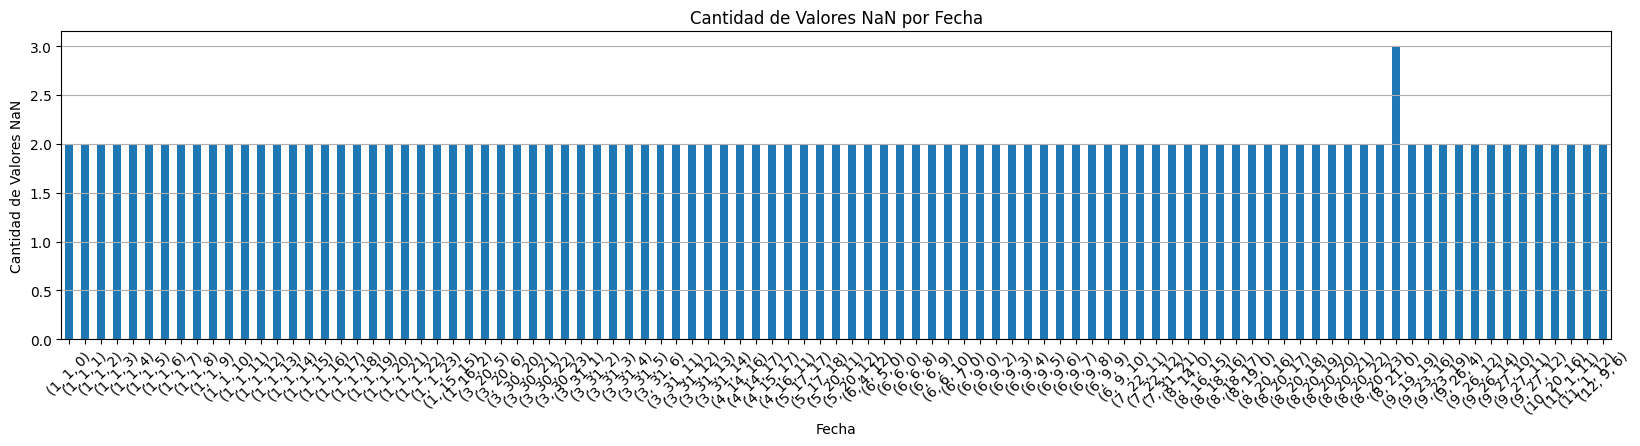

In [ ]:

#Se filtran datos faltantes
faltantes = df[df['pollution'].isnull()]


# Se agrupan datos por día, mes y hora, y se cuentan los NaNs en cada grupo
nan_por_fecha = faltantes.groupby([faltantes.index.month, faltantes.index.day, faltantes.index.hour]).size()

# Se filtran datos repetidos (>1 repetición)
instancias_filtradas = nan_por_fecha[nan_por_fecha > 1]


# Graficar la cantidad de NaN por fecha
instancias_filtradas.plot(kind='bar', figsize=(20, 4))
plt.title('Cantidad de Valores NaN por Fecha')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Valores NaN')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

Para observar los años en que suceden dichas repeticiones se utiliza el siguiente código.

La observación repetida 3 años fue en los años consecutivos 2012, 2013 y 2014. Sin embargo, al ser solo 1 en 96 en datos que no pareciesen seguir una tendencia clara con respecto al momento en donde se pierde la data (azar)

In [ ]:
#Se crean nuevas columnas
faltantes['año'] = faltantes.index.year
faltantes['mes'] = faltantes.index.month
faltantes['dia'] = faltantes.index.day
faltantes['hora'] = faltantes.index.hour

# Se agrupan las observaciones
repeticiones = faltantes.groupby(['mes', 'dia', 'hora']).apply(lambda x: x['año'].unique()).reset_index(name='años')

# Se cuentan la cantidad de NaNs por fila
repeticiones['cantidad_nan'] = repeticiones['años'].apply(lambda x: len(x))


# Se filtran los datos para más de 1 dato repetido
repeticiones1= repeticiones[repeticiones['cantidad_nan'] == 2]


# Mostrar los resultados
print(repeticiones1)

# Se muestra los datos repetidos para la instancia en donde esto sucede en 3 años
repeticiones2= repeticiones[repeticiones['cantidad_nan'] == 3]


# Mostrar resultado
print("Instancia de 3 años")
print(repeticiones2)

<ipython-input-187-ff4014344ec5>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  faltantes['año'] = faltantes.index.year
<ipython-input-187-ff4014344ec5>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  faltantes['mes'] = faltantes.index.month
<ipython-input-187-ff4014344ec5>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

      mes  dia  hora          años  cantidad_nan
0       1    1     0  [2010, 2011]             2
1       1    1     1  [2010, 2011]             2
2       1    1     2  [2010, 2011]             2
3       1    1     3  [2010, 2011]             2
4       1    1     4  [2010, 2011]             2
...   ...  ...   ...           ...           ...
1474    9   27    12  [2010, 2012]             2
1662   10   20    16  [2012, 2014]             2
1696   11    1    11  [2010, 2011]             2
1697   11    1    12  [2010, 2011]             2
1804   12    9     6  [2012, 2014]             2

[96 rows x 5 columns]
Instancia de 3 años
      mes  dia  hora                años  cantidad_nan
1239    8   21     0  [2012, 2013, 2014]             3


A pesar de lo anterior, si se toma en cuenta que las observaciones se obtuvieron cada 1 hora, el hecho de que estas se repitan independientemente año a año puede no indicar con claridad si la importancia de valores faltantes. en búsqueda de encontrar patrones más significativos, en donde los datos faltantes abarquen múltiples observaciones continuas, se tiene el siguiente código que lista todas las observaciones repetidas por más de 1 hora y los años en que sucedieron. De estas ninguna supero los 2 años de repetición,mientras que las que se repitieron 2 años destacan:



1.   Patrón 0 [2010 2011]: 23 horas (1-1 1:00 ~ 23:00)
2.   Patrón 58 [2010 2014]: 8 horas (6-9 2:00 ~ 10:00)
1.   Patron 83 [2012 2014]: 7 horas (8-20 16:00 ~ 23:00)

Mientras que de aquellos que no se repitieron más de un año destacan:
2.   Patrón 101 [2010]: 75 horas (9-27 17:00 ~ 9-30 20:00)
1.   Patrón 102 [2011]: 98 horas (10-3 13:00 ~ 10-7 15:00)
1.   Patrón 122 [2012]: 126 horas (12-23 06:00 ~ 12-28 12:00)







In [ ]:

# Inicializar lista con patrones encontrados
patrones_encontrados = []
orden = 0
# Iterar sobre las filas del DataFrame
for i in range(len(repeticiones) - 1):
    # Verificar si las filas son continuas en términos de hora
    if (((repeticiones.iloc[i + 1]['hora'] - repeticiones.iloc[i]['hora'] == 1) and (repeticiones.iloc[i + 1]['dia']== repeticiones.iloc[i]["dia"])) or \
       ((repeticiones.iloc[i + 1]['dia'] - repeticiones.iloc[i]['dia'] == 1 ) and (repeticiones.iloc[i + 1]['hora'] == 0 and repeticiones.iloc[i]['hora'] == 23))) and (set(repeticiones.iloc[i + 1]['años']) == set(repeticiones.iloc[i]["años"]) and len(repeticiones.iloc[i + 1]['años']) and len(repeticiones.iloc[i]['años'])):

        # Si las filas son continuas y la columna hora sigue un patrón, se guarda
        patron = {
            'inicio': repeticiones.iloc[i]['hora'],
            'fin': repeticiones.iloc[i + 1]['hora'],
            'mes': repeticiones.iloc[i]['mes'],
            'dia': repeticiones.iloc[i]['dia'],
            'orden': orden,
            'años': repeticiones.iloc[i]["años"]
        }
        patrones_encontrados.append(patron)
    else:
        orden = patrones_encontrados[-1]["orden"]+1;


j = 0;
i = 0;
total = 1;
orden_actual=0;
print(patrones_encontrados)
#Se muestran todos los patrones encontrados
while i < len(patrones_encontrados):
      if j == 0 :
        print("Patrón encontrado:", patrones_encontrados[i]['orden'])
        print("Inicio")
        print(f"Hora {patrones_encontrados[i]['inicio']}, día {patrones_encontrados[i]['dia']}"
              f", mes {patrones_encontrados[i]['mes']}")
        j=1
      if i != len(patrones_encontrados)-1:

        if ((patrones_encontrados[i+1]["orden"] == (orden_actual+1)) ) and j==1:
          orden_actual +=1
          j=0
          print("Final")
          print(f"Hora {patrones_encontrados[i]['fin']}, día {patrones_encontrados[i]['dia']}"
                f", mes {patrones_encontrados[i]['mes']} los años {patrones_encontrados[i]['años']}")
          print("Cantidad de horas:", total)
          total = 1
          print("\n\n")
        else:
          total = total + 1
      elif j==1:
          print("Final")
          print(f"Hora {patrones_encontrados[i]['fin']}, día {patrones_encontrados[i]['dia']}"
                f", mes {patrones_encontrados[i]['mes']} los años {patrones_encontrados[i]['años']}")
          print("Cantidad de horas:", total)
          total = 1
          print("\n\n")

      i +=1

[{'inicio': 0, 'fin': 1, 'mes': 1, 'dia': 1, 'orden': 0, 'años': array([2010, 2011], dtype=int32)}, {'inicio': 1, 'fin': 2, 'mes': 1, 'dia': 1, 'orden': 0, 'años': array([2010, 2011], dtype=int32)}, {'inicio': 2, 'fin': 3, 'mes': 1, 'dia': 1, 'orden': 0, 'años': array([2010, 2011], dtype=int32)}, {'inicio': 3, 'fin': 4, 'mes': 1, 'dia': 1, 'orden': 0, 'años': array([2010, 2011], dtype=int32)}, {'inicio': 4, 'fin': 5, 'mes': 1, 'dia': 1, 'orden': 0, 'años': array([2010, 2011], dtype=int32)}, {'inicio': 5, 'fin': 6, 'mes': 1, 'dia': 1, 'orden': 0, 'años': array([2010, 2011], dtype=int32)}, {'inicio': 6, 'fin': 7, 'mes': 1, 'dia': 1, 'orden': 0, 'años': array([2010, 2011], dtype=int32)}, {'inicio': 7, 'fin': 8, 'mes': 1, 'dia': 1, 'orden': 0, 'años': array([2010, 2011], dtype=int32)}, {'inicio': 8, 'fin': 9, 'mes': 1, 'dia': 1, 'orden': 0, 'años': array([2010, 2011], dtype=int32)}, {'inicio': 9, 'fin': 10, 'mes': 1, 'dia': 1, 'orden': 0, 'años': array([2010, 2011], dtype=int32)}, {'inicio

En cuanto al resto de variables, se busca la correlación que estas tienen con los datos perdidos.

De la tabla de correlación se puede ver que no hay correlación fuerte entre los datos faltantes y las demás variables.

In [ ]:
#Se crea columna fecha para la correlación
df['fecha'] = pd.to_numeric(df.index)

# Calcular la cantidad de datos faltantes en la columna específica
datos_faltantes_columna = df["pollution"].isnull()

# Determinar si hay alguna correlación entre la columna con datos faltantes y otras variables
correlaciones = df.corrwith(datos_faltantes_columna)

# Imprimir las correlaciones
print("Correlaciones con la columna que tiene datos faltantes:")
print(correlaciones)

df.drop("fecha", axis=1)

Correlaciones con la columna que tiene datos faltantes:
pollution         NaN
dew          0.020887
temp         0.017303
press        0.002083
wnd_dir      0.001030
wnd_spd      0.002012
snow        -0.015430
rain         0.000160
hum          0.010927
fecha       -0.130346
dtype: float64


,pollution,dew,temp,press,wnd_dir,wnd_spd,snow,rain,hum
date,,,,,,,,,
2010-01-01 00:00:00,NaN,-21,-11.0,1021.0,2,1.79,0,0,0.435295
2010-01-01 01:00:00,NaN,-21,-12.0,1020.0,2,4.92,0,0,0.471521
2010-01-01 02:00:00,NaN,-21,-11.0,1019.0,2,6.71,0,0,0.435295
2010-01-01 03:00:00,NaN,-21,-14.0,1019.0,2,9.84,0,0,0.554426
2010-01-01 04:00:00,NaN,-20,-12.0,1018.0,2,12.97,0,0,0.514135
...,...,...,...,...,...,...,...,...,...
2014-12-31 19:00:00,8.0,-23,-2.0,1034.0,2,231.97,0,0,0.183270
2014-12-31 20:00:00,10.0,-22,-3.0,1034.0,2,237.78,0,0,0.215538
2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,2,242.70,0,0,0.215538


Se grafica la columna pollution con valores NaNs incluidos

In [ ]:

fig = px.line(df, x=df.index, y='pollution', title='Pollution graph')
fig.update_xaxes(rangeslider_visible=True,
                 rangeselector=dict(
                     buttons=list([
                         dict(count=1, label='1y', step="year", stepmode="backward"),
                         dict(count=2, label='2y', step="year", stepmode="backward"),
                         dict(count=3, label='3y', step="year", stepmode="backward"),
                         dict(step="all")
                     ])
                 )
)
fig.show()

Se sobreescriben los valores NaN a partir de interpolación lineal

In [ ]:
#Interpolación lineal para reemplazar datos faltantes
df['pollution'] = df['pollution'].interpolate(method='linear').bfill()



In [ ]:
df.isna().sum()

,0
pollution,0
dew,0
temp,0
press,0
wnd_dir,0
wnd_spd,0
snow,0
rain,0


## Valores anómalos

Se procede a analizar la existencia de datos duplicados en el dataset. En total, se llega a que hay 14 observaciones con datos repetidos. Al analizarlas se puede ver que ningún dato se repite más de 2 veces, además estas repeticiones suceden en momentos similares, incluso si son en años distintos (mismos meses con cercanía en los días), por ende es natural pensar que la presencia de este tipo de observaciones es una posibilidad. Además, se imprime el porcentaje de observaciones repetidas, dando un total de 0.03%. Con este valor y teniendo una idea del posible origen de dichas observaciones, se cree que no vale la pena hacer algún procedimiento extra para tratarlas. Es así como se decide ignorar.

In [ ]:
print("La cantidad de duplicados son: ",len(df[df.duplicated()]))

La cantidad de duplicados son:  12


Se muestran las observaciones repetidas

In [ ]:

# Ordenar los datos por todas las columnas
df_sorted = df.sort_values(by=list(df.columns))

# Seleccionar solo los datos duplicados y mantener todos los duplicados (keep=False)
duplicated_sorted = df_sorted[df_sorted.duplicated(keep=False)]

duplicated_sorted

,pollution,dew,temp,press,wnd_dir,wnd_spd,snow,rain
date,,,,,,,,
2012-07-14 13:00:00,14.0,16,31.0,1004.0,3,6.26,0,0
2014-07-21 21:00:00,14.0,16,31.0,1004.0,3,6.26,0,0
2012-02-23 13:00:00,15.0,-19,5.0,1026.0,2,1.79,0,0
2013-11-19 11:00:00,15.0,-19,5.0,1026.0,2,1.79,0,0
2012-03-15 03:00:00,54.0,-8,-2.0,1027.0,0,0.89,0,0
2014-03-10 04:00:00,54.0,-8,-2.0,1027.0,0,0.89,0,0
2013-02-23 10:00:00,58.0,-15,2.0,1029.0,0,0.89,0,0
2014-12-13 12:00:00,58.0,-15,2.0,1029.0,0,0.89,0,0
2012-07-25 17:00:00,79.0,25,28.0,1006.0,0,0.89,0,0


In [ ]:
#Se imprime la cantidad de repetidos
print("La cantidad de index duplicados son: ", df.index.duplicated().sum())

La cantidad de index duplicados son:  0


Porcentaje de repetidos

In [ ]:
# Total de repetidos en el dataframe
total_rep = len(df[df.duplicated()])

# Total de datos
total_datos = df.shape[0]

# Proporción
prop_rep = (total_rep / total_datos) * 100

print(f"Porcentaje de valores repetidos en relación al total de datos: {prop_rep:.6f}%")

Porcentaje de valores repetidos en relación al total de datos: 0.027382%


**Outliers**

Mediante gráficos boxplot, se revisa la existencia de outliers en cada una de las variables. De acuerdo a los gráficos, tlas variables con outliers son pollution, wnd_spd, snow y rain.

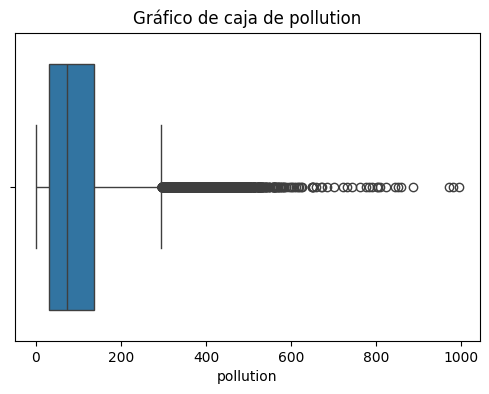

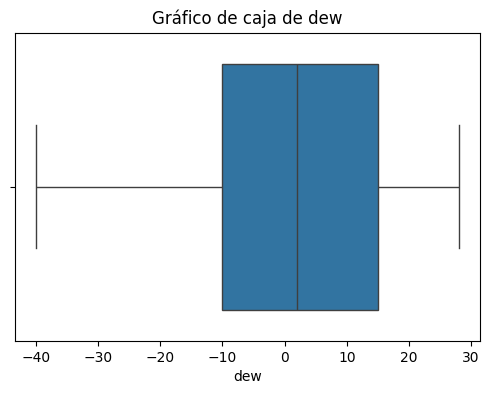

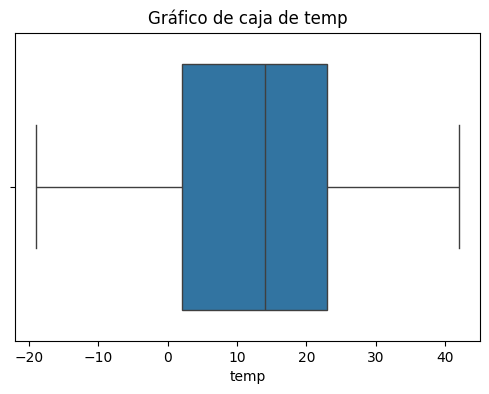

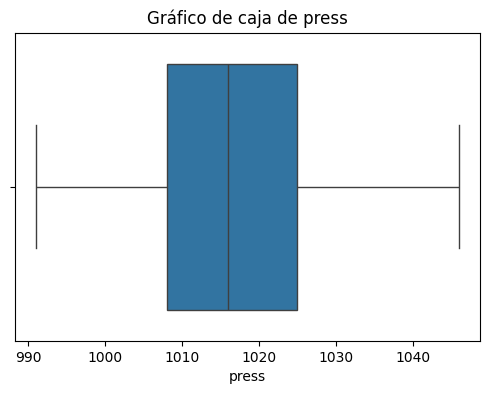

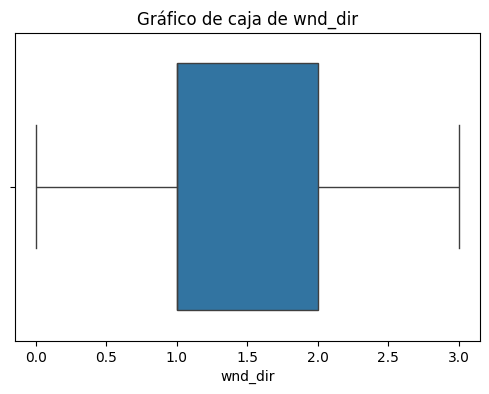

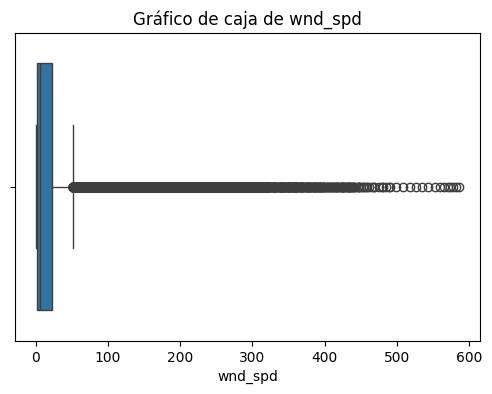

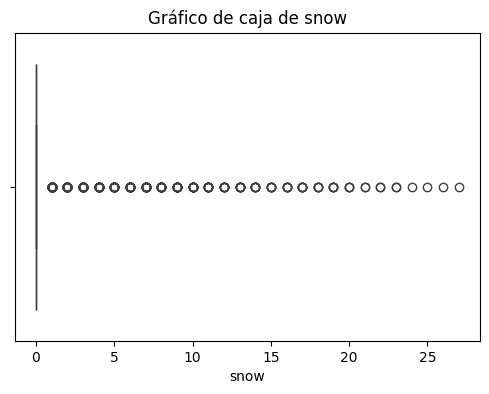

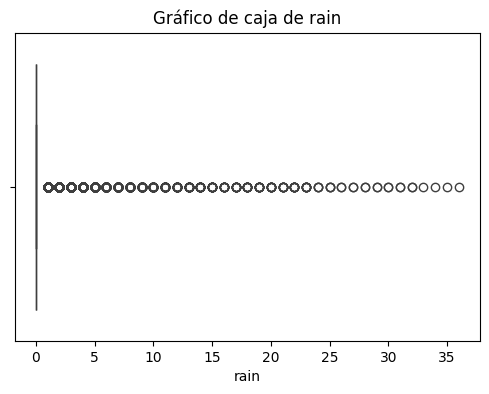

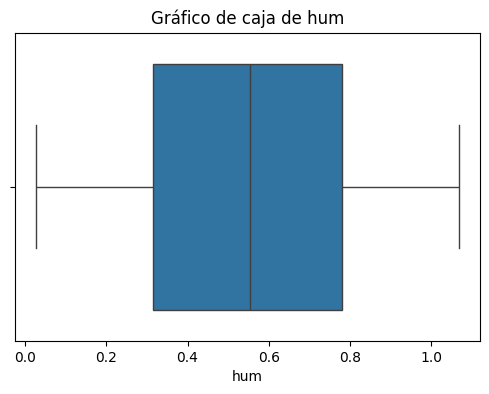

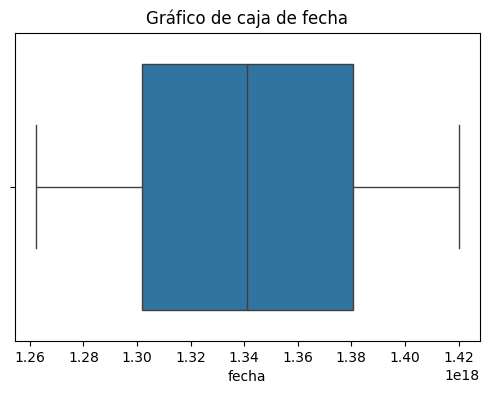

In [ ]:
for col in df.columns:
    plt.figure(figsize=(6, 4))  # Tamaño del gráfico individual
    sns.boxplot(x=df[col])
    plt.title('Gráfico de caja de {}'.format(col))
    plt.xlabel(col)
    plt.show()

Se define función que suma la cantidad de outliers de una variable de acuerdo al método IQR con 1,5.

In [ ]:
def sumarOutliers(nombre):
  Q1 = np.percentile(df[nombre], 25)
  Q3 = np.percentile(df[nombre], 75)

  # Calcular el rango intercuartil
  IQR = Q3 - Q1
  # Calcular el límite superior
  LS = Q3 + 1.5 * IQR
  # Calcular el límite inferior
  LI = Q1 - 1.5 * IQR
  # Contar la cantidad de puntos que están por encima de LS y por debajo de LI
  cont1 = np.sum(df[nombre] > LS)
  cont2 = np.sum(df[nombre] < LI)

  return (cont1 + cont2)


In [ ]:
for columna in df:
  total = sumarOutliers(columna)
  print("Hay ", total, "outliers para la variable ", columna)
  porcentaje = (total / df.shape[0])*100
  print("El porcentaje de dicho valor es: ",porcentaje, "%")
  print("")

Hay  1884 outliers para la variable  pollution
El porcentaje de dicho valor es:  4.2990142387732755 %

Hay  0 outliers para la variable  dew
El porcentaje de dicho valor es:  0.0 %

Hay  0 outliers para la variable  temp
El porcentaje de dicho valor es:  0.0 %

Hay  0 outliers para la variable  press
El porcentaje de dicho valor es:  0.0 %

Hay  0 outliers para la variable  wnd_dir
El porcentaje de dicho valor es:  0.0 %

Hay  5101 outliers para la variable  wnd_spd
El porcentaje de dicho valor es:  11.639740781307047 %

Hay  368 outliers para la variable  snow
El porcentaje de dicho valor es:  0.8397225264695144 %

Hay  1808 outliers para la variable  rain
El porcentaje de dicho valor es:  4.125593282219788 %



Se instala librería para visualizar los resultados del método IQR

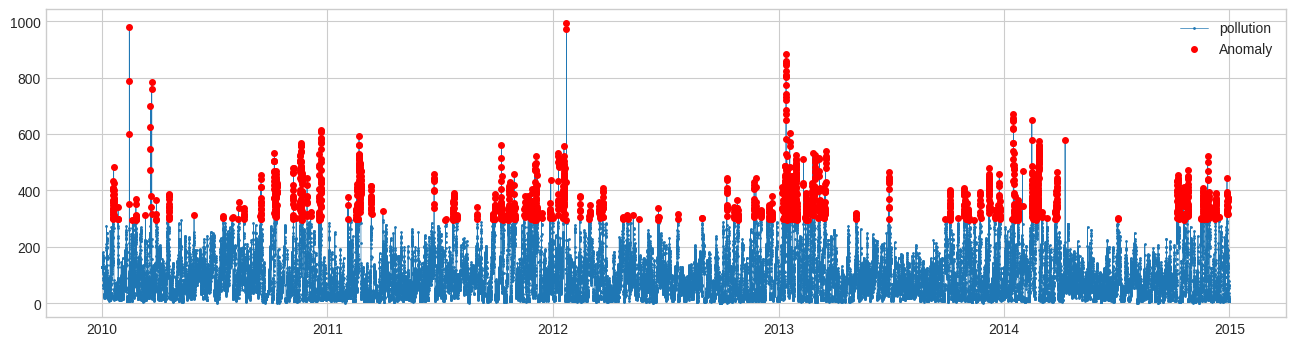

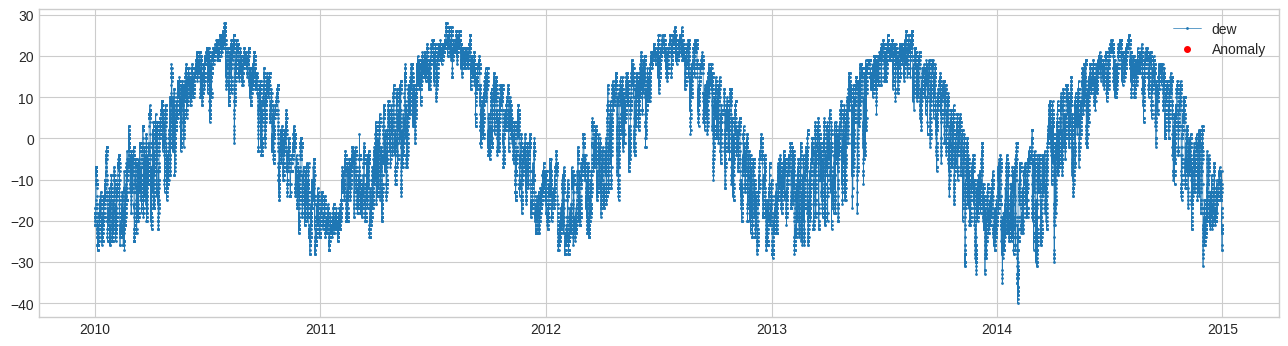

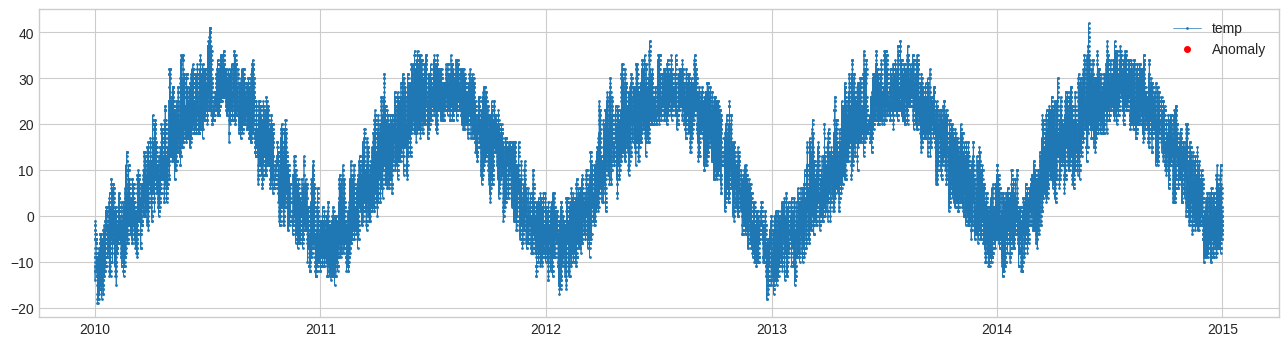

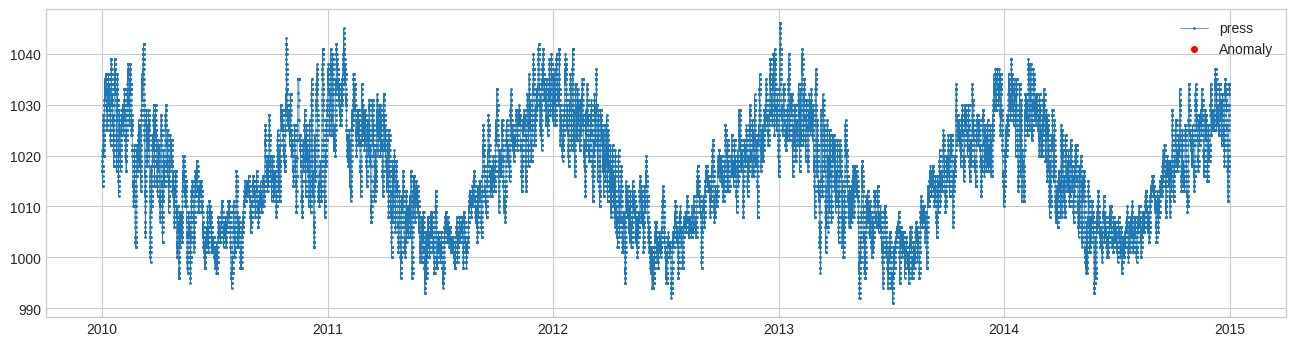

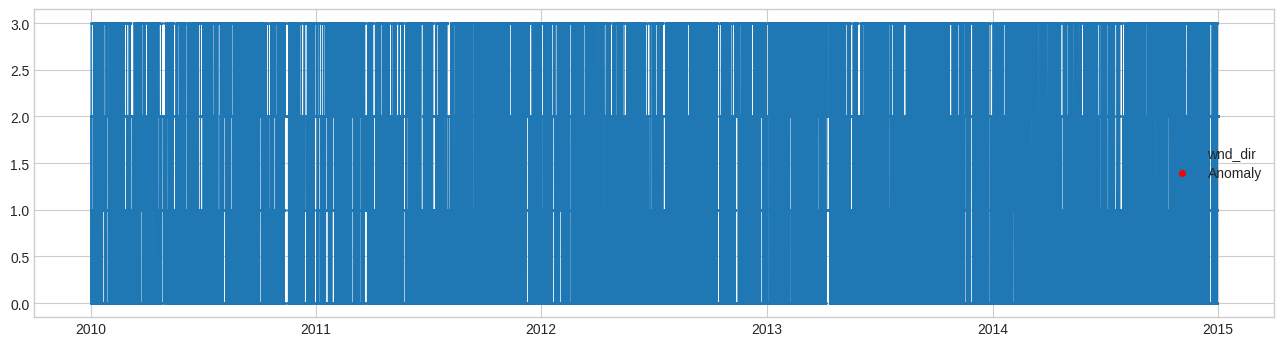

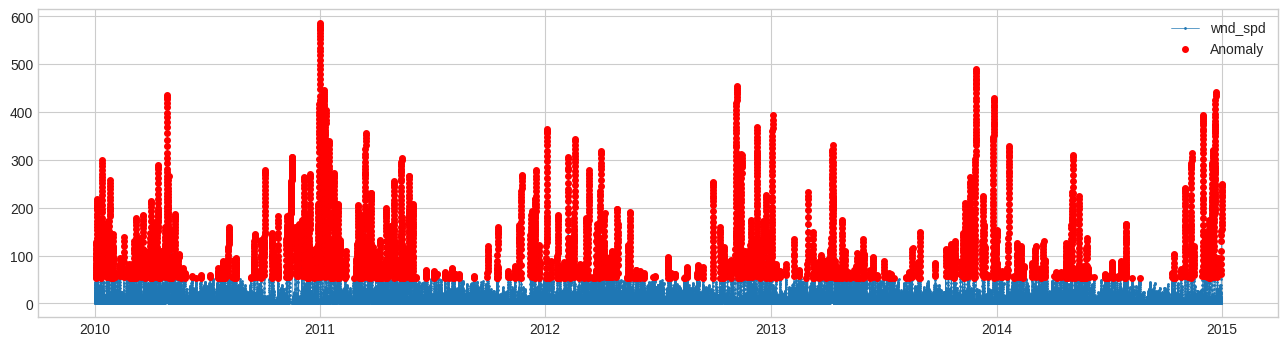

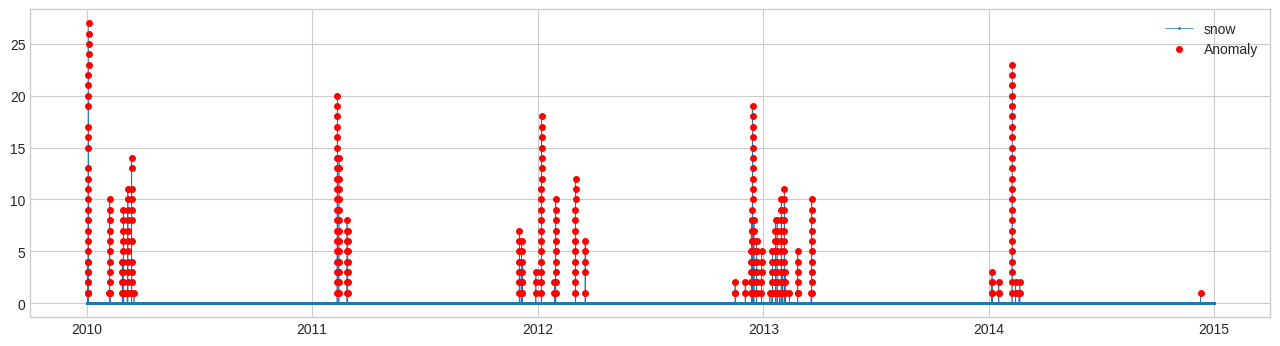

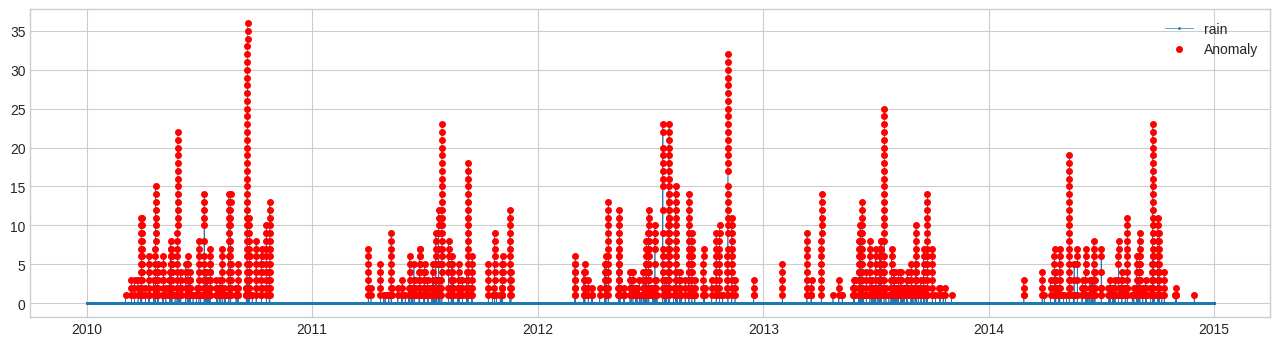

In [ ]:
from adtk.visualization import plot as adtkPlot
from adtk.detector import InterQuartileRangeAD

iqr_detector = InterQuartileRangeAD(c=1.5)

for columna in df:
  anomalies = iqr_detector.fit_detect(df[columna])
  adtkPlot(df[columna], anomaly=anomalies, anomaly_color="red", anomaly_tag="marker")


Outliers de Pollution

A modo de entender de mejor manera los outliers de la variable pollution, se inicia por ver la proporción de observaciones de acuerdo a la clasificación explicada en el documento introductorio al dataset, en donde se estipula que cuando la polución es menor a 35 µg/m³ se considera un nivel bajo o low, sobre 35 µg/m³ y bajo 150 µg/m³ se considera como un episodio de polución o polluting episode, y sobre 150 µg/m³ se toma como un nivel muy alto o very high. En el análisis realizado en el paper, se llega a que en un año las observaciones Low sucedieron el 23% del tiempo, mientras que las very high duraron un 22% del tiempo. En consecuencia, los episodios abarcaron el 55% del tiempo. Todos los años existe una proporción similar. A continuación se calculan estos valores para ver si coinciden con lo visto en el documento. Para bajo, episodio y alto se obtuvieron como porcentajes 28.5%, 50.3% y 21.1%, respectivamente, valores que se asemejan bastante a los originales.

In [ ]:
def distribucionPolucion():
  l1 = 35
  l2 = 150
  low = 0
  episode = 0
  high = 0

  for indice, fila in df.iterrows():
    if fila["pollution"] <= l1:
      low+=1
    elif fila["pollution"] > l1 and fila["pollution"] <= l2:
      episode+=1
    elif fila["pollution"] > l2:
      high+=1
  return [low, episode, high]


In [ ]:
resultado = distribucionPolucion()
print(resultado)
print("Hay ", resultado[0], "valores Low en la variable pollution")
porcentaje1 = (resultado[0] / df.shape[0])*100
print("El porcentaje de Low en el dataset es: ",porcentaje1, "%")
print("Hay ", resultado[1], "valores Episode en la variable pollution")
porcentaje2 = (resultado[1] / df.shape[0])*100
print("El porcentaje de Episode en el dataset es: ",porcentaje2, "%")
print("Hay ", resultado[2], "valores High en la variable pollution")
porcentaje3 = (resultado[2] / df.shape[0])*100
print("El porcentaje de High en el dataset es: ",porcentaje3, "%")


[12507, 22058, 9259]
Hay  12507 valores Low en la variable pollution
El porcentaje de Low en el dataset es:  28.539156626506024 %
Hay  22058 valores Episode en la variable pollution
El porcentaje de Episode en el dataset es:  50.333150784958015 %
Hay  9259 valores High en la variable pollution
El porcentaje de High en el dataset es:  21.12769258853596 %


Ahora bien, en términos de los valores alcanzados por la variable pollution se pueden apreciar ciertos puntos que superan con creces los 150 µg/m³, llegando incluso a sixtuplicarlo. Esto es un primer punto en donde hay sospecha de outliers a eliminar. Luego, buscando en internet se llega a que el registro record de PM2.5 en Beijing sucedió el 12 de enero de 2013 (https://www.theguardian.com/world/2013/feb/16/chinese-struggle-through-airpocalypse-smog https://earthobservatory.nasa.gov/images/80152/air-quality-suffering-in-china), lo que significa que valores superiores a la medida máxima de dicho día no son correctas. A continuación se filtran dichas fechas.

In [ ]:
# 1. Aislar el valor en la fecha específica
maximo = df.loc["2013-01-12", 'pollution'].max()

# 2. Filtrar las filas con valores superiores al valor encontrado
filas_superiores = df[df['pollution'] > maximo]

In [ ]:
print(filas_superiores)

                     pollution  dew  temp   press  wnd_dir  wnd_spd  snow  \
date                                                                        
2010-02-14 01:00:00      980.0  -14  -7.0  1029.0        0     0.89     0   
2012-01-23 01:00:00      994.0  -24 -12.0  1032.0        2     4.92     0   
2012-01-23 02:00:00      972.0  -24 -12.0  1032.0        2     8.05     0   

                     rain  
date                       
2010-02-14 01:00:00     0  
2012-01-23 01:00:00     0  
2012-01-23 02:00:00     0  


Para eliminar dichas variables se pasan a valores NaN y despues se aplica regresión lineal para reemplazarlas.

In [ ]:
df.loc[df['pollution'] > maximo, 'pollution'] = float('NaN')
#Interpolación lineal para reemplazar datos faltantes
df['pollution'] = df['pollution'].interpolate(method='linear')

In [ ]:
df.isna().sum()

,0
pollution,0
dew,0
temp,0
press,0
wnd_dir,0
wnd_spd,0
snow,0
rain,0


Outliers de wnd_spd

Se procede a analizar los outliers de wnd_spd. Se sabe que esta es una variable que se mide en m/s, por lo que tener valores superiores a 100 pareciese ser irrealista. Sin embargo, hay que tener en cuenta que esta variable no mide directamente la velocidad del viento, sino que corresponde a la velocidad de viento acumulada. Esta, de acuerdo al documento asociado al dataset, se acumula mientras la dirección del viento no cambie, e inclusive, los vientos con dirección en CV (calma) acumulan velocidade3s de 0.445 m/s. Es así como, para confirmar que estos valores son razonables, se ha de revisar las direcciones asociadas.

Para revisar wnd_spd, primero se revisa si es que, cuando se cambia de dirección, la nueva velocidad marcada está en un rango de 0 a 33 m/s(máximo en la escala de Bufordt), puesto que se toma el peor de los casos, en donde aparece un viento fuerte dentro de la normalidad en una dirección distinta. Luego, se revisa que, si se mantiene la dirección, existen descensos en lugar de aumentos. Finalmente se revisa si el aumento supera los 33 m/s, que de acuerdo con la escala Beufordt es el máximo de velocidad del viento en m/s. Es así como se registran 0 anomalías con respecto a esta variable. En conclusión, no se debiese eliminar ningún dato anómalo.


In [ ]:
anomalia = []
outliers = df[iqr_detector.fit_detect(df["wnd_spd"])]
for indice in range(1, len(df)):
  if (df.iloc[indice]["wnd_dir"] != df.iloc[indice - 1]["wnd_dir"]) and (df.iloc[indice]["wnd_spd"] - df.iloc[indice - 1]["wnd_spd"]  > 33):
    anomalia.append(df.index[indice])
  if (df.iloc[indice]["wnd_dir"] == df.iloc[indice - 1]["wnd_dir"]) and (df.iloc[indice]["wnd_spd"] - df.iloc[indice - 1]["wnd_spd"] < 0):
    anomalia.append(df.index[indice])

  elif (df.iloc[indice]["wnd_dir"] == df.iloc[indice - 1]["wnd_dir"]) and (df.iloc[indice]["wnd_spd"] - df.iloc[indice - 1]["wnd_spd"] > 33):
    anomalia.append(df.index[indice])


print("La cantidad de anomalias son: ", len(anomalia))





La cantidad de anomalias son:  0


Outliers de Snow y Rain

Estas son variables que miden las horas acumuladas de nieve y lluvia en la región. A pesar de tener datos atípicos, al ver sus valores máximos (27 para nieve y 36 para lluvia) se puede concluir que estos son acordes con la realidad. Sin embargo, al ser horas acumuladas y teniendo observaciones medidas cada hora, se puede revisar si las medidas obtenidas son correctas. A modo de ejemplo, si en una hora se tienen 20 horas acumuladas de nieve, lo lógico es que en la siguiente medición (1 hora después) si sigue nevando esta variable aumente en 1, es decir 21 horas y no valores superiores. Esto se revisará a continuación tanto para snow como rain. Como resultado, snow tiene 6 anomalías y rain tiene 53 anomalias. De igual forma, se revisa si dichas anomalías forman parte de los outliers respectivos, y en efecto, son outliers. A modo de tratamiento, se "suavizan" las variables, cambiando a 1 los aumentos superiores a 1.

In [ ]:
anomaliaSnow = []
outliersSnow = df[iqr_detector.fit_detect(df["snow"])]
for indice in range(1, len(df)):
  if (df.iloc[indice]["snow"] - df.iloc[indice - 1]["snow"]  > 1) and df.iloc[indice]["snow"] != 0:
    anomaliaSnow.append(df.index[indice])

print("La cantidad de anomalias son: ", len(anomaliaSnow))

La cantidad de anomalias son:  6


In [ ]:
contenidoSnow = outliersSnow.index.isin(anomaliaSnow)
presentesSnow = []
# Filtrar lista_fecha para obtener solo los elementos con valor True
for indice, elemento in enumerate(contenidoSnow):
  if elemento == True:
    presentesSnow.append(outliersSnow.index[indice])

print("la cantidad de anomalias que son outliers son:", len(presentesSnow))

la cantidad de anomalias que son outliers son: 6


In [ ]:
anomaliaRain = []
outliersRain = df[iqr_detector.fit_detect(df["rain"])]
for indice in range(1, len(df)):
  if (df.iloc[indice]["rain"] - df.iloc[indice - 1]["rain"]  > 1) and df.iloc[indice]["rain"] != 0:
    anomaliaRain.append(df.index[indice])

print("La cantidad de anomalias son: ", len(anomaliaRain))

La cantidad de anomalias son:  53


In [ ]:
contenidoRain = outliersRain.index.isin(anomaliaRain)
presentesRain = []
# Filtrar lista_fecha para obtener solo los elementos con valor True
for indice, elemento in enumerate(contenidoRain):
  if elemento == True:
    presentesRain.append(outliersRain.index[indice])


print("la cantidad de anomalias que son outliers son:", len(presentesRain))

la cantidad de anomalias que son outliers son: 53


In [ ]:
for indice in range(1, len(df)):
  if (df.iloc[indice]["snow"] - df.iloc[indice - 1]["snow"]  != 1) and df.iloc[indice]["snow"] != 0:
    df.loc[df.index[indice], "snow"] = df.loc[df.index[indice - 1], "snow"] + 1
  if (df.iloc[indice]["rain"] - df.iloc[indice - 1]["rain"]  != 1) and df.iloc[indice]["rain"] != 0:
    df.loc[df.index[indice], "rain"] = df.loc[df.index[indice - 1], "rain"] + 1



In [ ]:
anomaliaSnow = []
outliersSnow = df[iqr_detector.fit_detect(df["snow"])]
for indice in range(1, len(df)):
  if (df.iloc[indice]["snow"] - df.iloc[indice - 1]["snow"]  > 1) and df.iloc[indice]["snow"] != 0:
    anomaliaSnow.append(df.index[indice])

print("La cantidad de anomalias son: ", len(anomaliaSnow))

La cantidad de anomalias son:  0


Posibles soluciones:

Winsorization

In [ ]:
def winsorize(data, name):

  q_low = np.percentile(data[name], 25)
  q_high = np.percentile(data[name], 75)


  # Calcular el rango intercuartil
  IQR = q_high - q_low
  # Calcular el límite superior
  LS = q_high + 1.5 * IQR
  # Calcular el límite inferior
  LI = q_low - 1.5 * IQR

  df2 = data[name];
  df2[name] = data[name].where(data[name] > LI, q_low)
  df2[name] = data[name].where(data[name] < LS, q_high)

  return df2

<ipython-input-94-91f0fff0fcf8>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[name] = data[name].where(data[name] > LI, q_low)


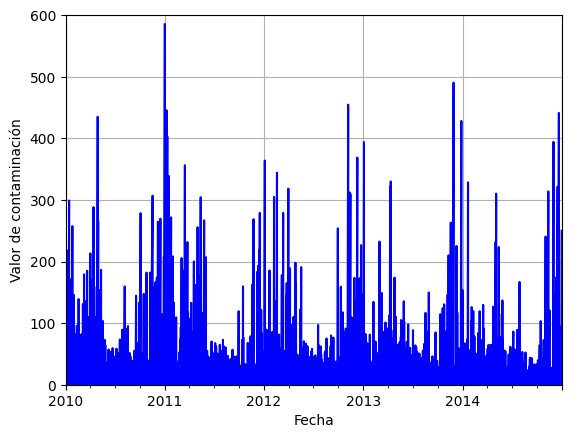

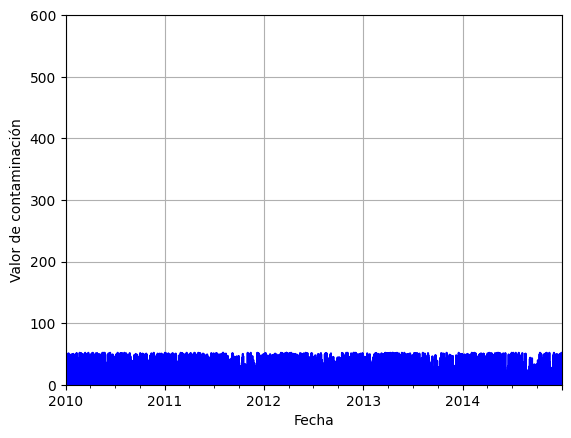

In [ ]:
nombre = "wnd_spd"

limpio = winsorize(df, nombre)



df[nombre].plot(color='blue')
plt.ylim(0, 600)
plt.xlabel('Fecha')
plt.ylabel('Valor de contaminación')
plt.grid(True)
plt.show()

limpio[nombre].plot(color='blue')
plt.ylim(0, 600)
plt.xlabel('Fecha')
plt.ylabel('Valor de contaminación')
plt.grid(True)
plt.show()



Solución 2: Interpolación lineal

In [ ]:
def interpolacion(data, name):

  q_low = np.percentile(data[name], 25)
  q_high = np.percentile(data[name], 75)


  # Calcular el rango intercuartil
  IQR = q_high - q_low
  # Calcular el límite superior
  LS = q_high + 1.5 * IQR
  # Calcular el límite inferior
  LI = q_low - 1.5 * IQR

  df2 = data[name];
  df2[name] = data[name].where(data[name] > LI, np.NaN)
  df2[name] = data[name].where(data[name] < LS, np.NaN)

  return df2

<ipython-input-98-9326b73900d5>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[name] = data[name].where(data[name] > LI, np.NaN)


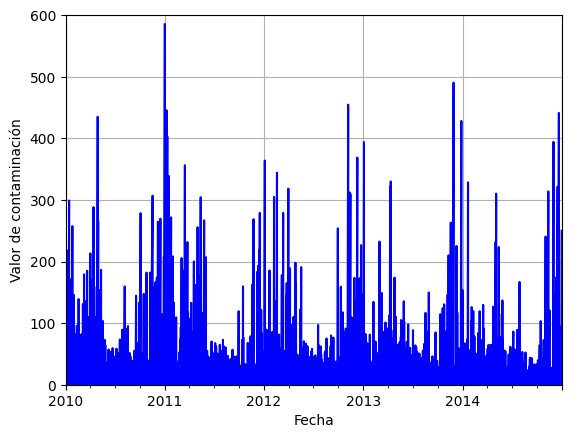

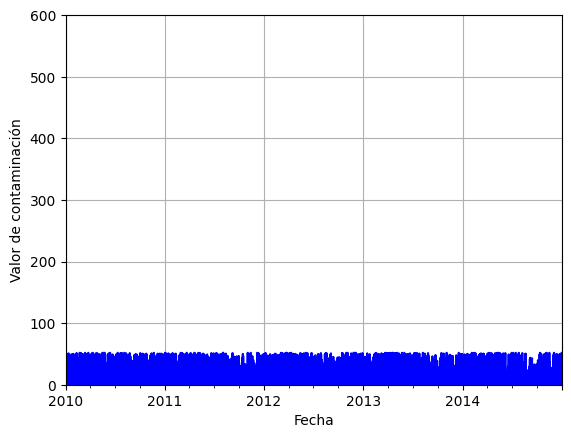

In [ ]:
nombre = "wnd_spd"


limpio2 = interpolacion(df, nombre)
limpio2[nombre] = limpio2[nombre].interpolate(method='linear').bfill().ffill()


df[nombre].plot(color='blue')
plt.ylim(0, 600)
plt.xlabel('Fecha')
plt.ylabel('Valor de contaminación')
plt.grid(True)
plt.show()

limpio2[nombre].plot(color='blue')
plt.ylim(0, 600)
plt.xlabel('Fecha')
plt.ylabel('Valor de contaminación')
plt.grid(True)
plt.show()


Se prueban otros métodos para detectar outliers, pero sin conocer una aprocximación del parámetro contaminación, aplicando la cantidad de outliers detectados por el método IQR se llegan a los mismos resultados (random forest) o resultados que no son satisfactorios (LOF).

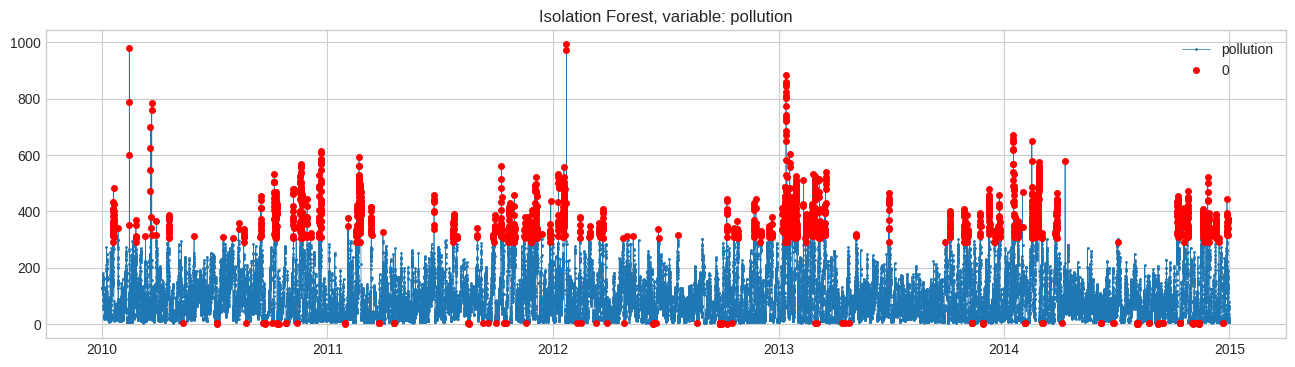

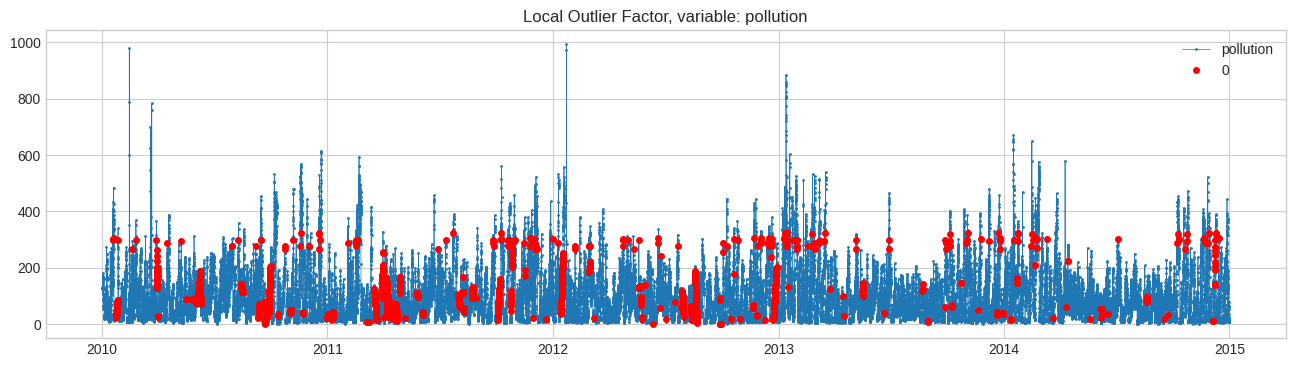

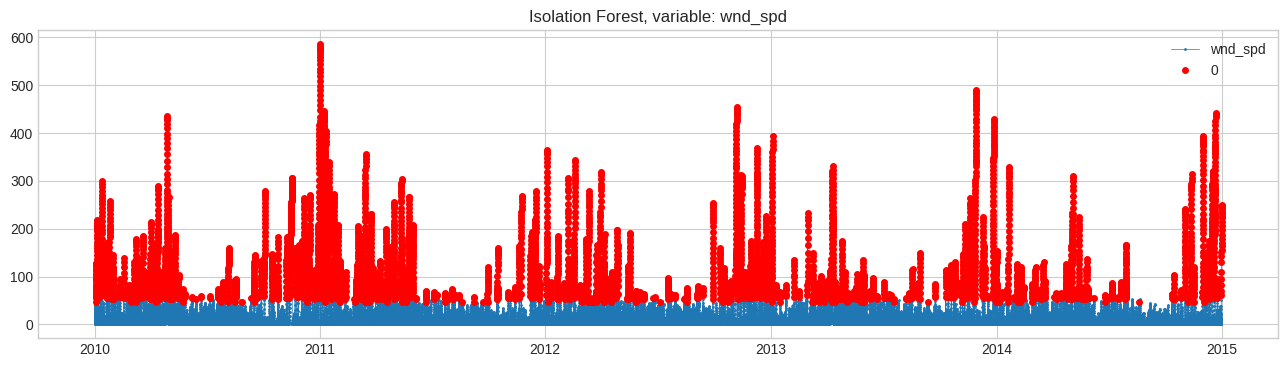

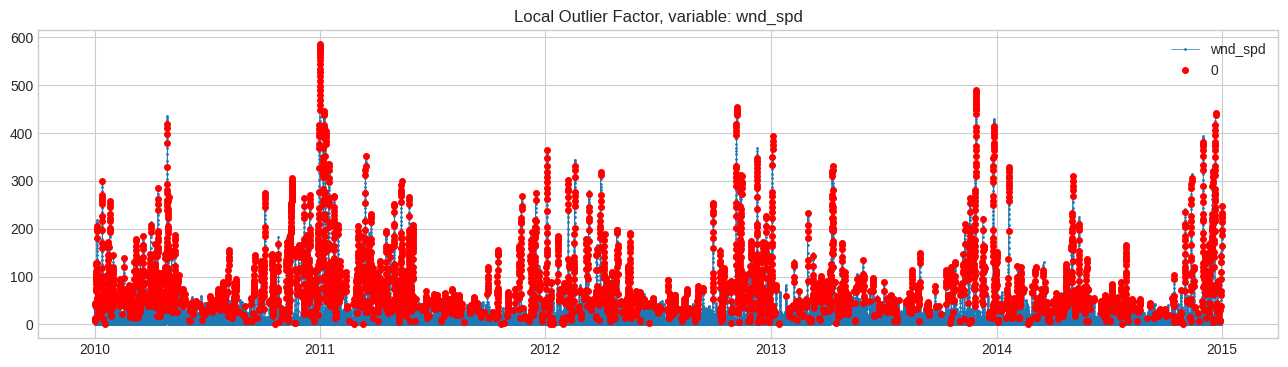

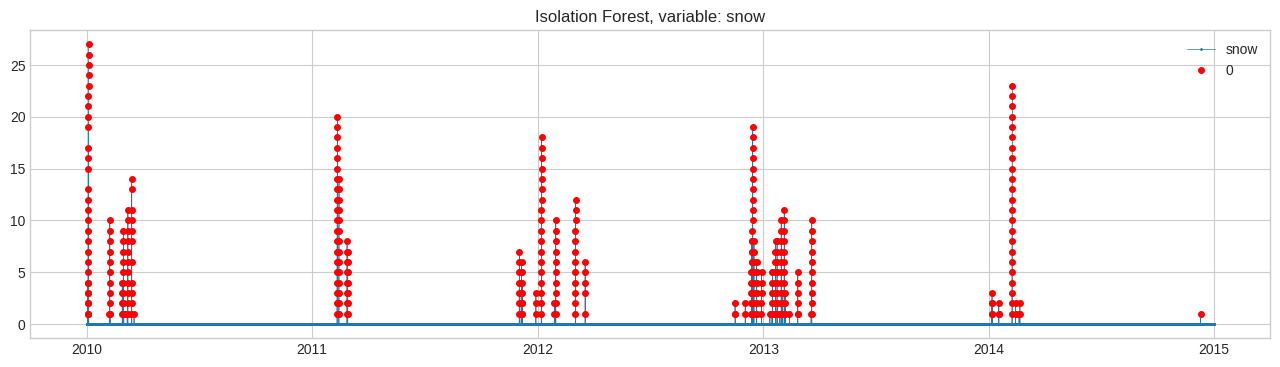

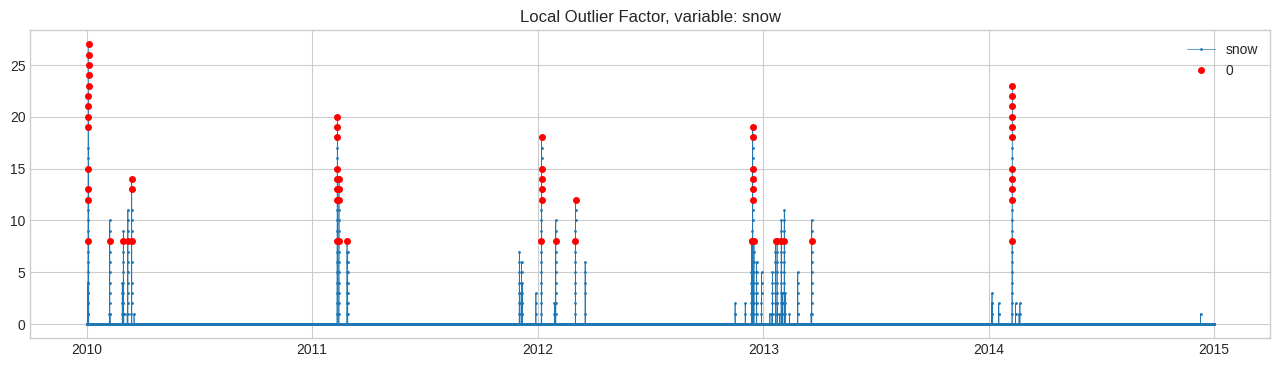

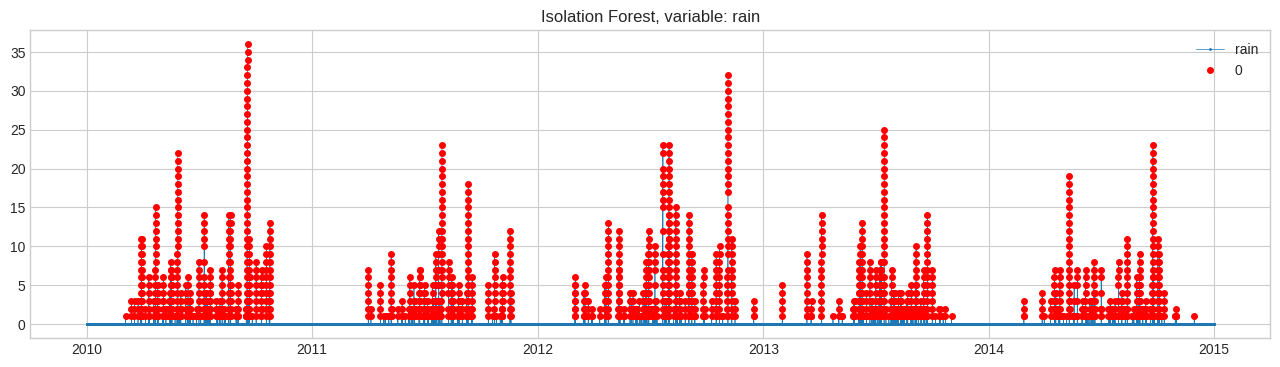

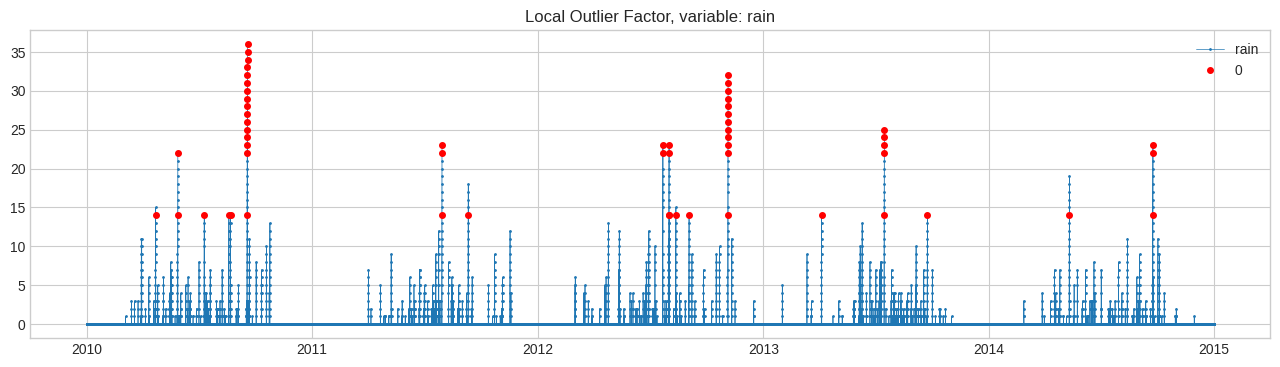

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

for name in df:

  outliers_fraction = sumarOutliers(name) / (df.shape[0])
  if outliers_fraction > 0:
    # IsFo
    model1 =  IsolationForest(contamination=outliers_fraction)
    model1.fit(df[name].values.reshape(-1, 1))
    anomaly1 = model1.fit_predict(df[name].values.reshape(-1, 1))

    # LOF
    model2 =  LocalOutlierFactor(contamination=outliers_fraction)
    model2.fit(df[name].values.reshape(-1, 1))
    anomaly2 = model2.fit_predict(df[name].values.reshape(-1, 1))


    anomaly1 = pd.DataFrame(anomaly1)
    anomaly1.index = df.index
    anomaly2 = pd.DataFrame(anomaly2)
    anomaly2.index = df.index
    # visualization
    anomaly1 = anomaly1.replace(1, 0)
    anomaly1 = anomaly1.replace(-1, 1)
    anomaly2 = anomaly2.replace(1, 0)
    anomaly2 = anomaly2.replace(-1, 1)

    adtkPlot(df[name], anomaly=anomaly1, anomaly_color="red", anomaly_tag="marker")
    plt.title('Isolation Forest, variable: {}'.format(name))

    adtkPlot(df[name], anomaly=anomaly2, anomaly_color="red", anomaly_tag="marker")
    plt.title('Local Outlier Factor, variable: {}'.format(name))

Se sobreescriben los valores NaN a partir de interpolación lineal

In [ ]:
#Interpolación lineal para reemplazar datos faltantes
df['pollution'] = df['pollution'].interpolate(method='linear').bfill()



In [ ]:
df.isna().sum()

,0
pollution,0
dew,0
temp,0
press,0
wnd_dir,0
wnd_spd,0
snow,0
rain,0


## Normalización de los datos


A continuación se aplica normalización Z-score sobre los datos para hacer el análisis de variables, no para utilizar en los modelos de aprendizaje profundo.

In [ ]:
def normalizar(data, name):
  columna = (data[name] - data[name].mean()) / data[name].std()
  return columna

In [ ]:
dfNorm = pd.DataFrame()

for name in df:
  dfNorm[name] = normalizar(df, name)




In [ ]:
dfNorm.describe()

,pollution,dew,temp,press,wnd_dir,wnd_spd,snow,rain
count,4.382400e+04,4.382400e+04,4.382400e+04,4.382400e+04,4.382400e+04,4.382400e+04,4.382400e+04,4.382400e+04
mean,-4.053388e-17,-2.075335e-17,-5.188337e-18,4.871848e-15,1.102522e-17,-2.594168e-17,-1.232230e-17,-9.079590e-18
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.083034e+00,-2.897247e+00,-2.578041e+00,-2.478177e+00,-1.425118e+00,-4.686831e-01,-6.983091e-02,-1.379130e-01
25%,-7.522442e-01,-8.187408e-01,-8.565336e-01,-8.226607e-01,-3.589981e-01,-4.418888e-01,-6.983091e-02,-1.379130e-01
50%,-2.781121e-01,1.266183e-02,1.271848e-01,-4.359406e-02,-3.589981e-01,-3.703040e-01,-6.983091e-02,-1.379130e-01
75%,4.165467e-01,9.133480e-01,8.649737e-01,8.328559e-01,7.071218e-01,-3.957437e-02,-6.983091e-02,-1.379130e-01
max,8.686294e+00,1.814034e+00,2.422528e+00,2.877906e+00,1.773242e+00,1.123183e+01,3.361874e+01,2.629314e+01


## Reducción de dimensionalidad

### Usando Random Forest


In [ ]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

# Divide los datos en características (X) y la variable objetivo (y)
X = dfNorm.drop('pollution', axis=1)  # Eliminar la columna 'pollution' para obtener las características
y = dfNorm['pollution']  # Variable objetivo


# Entrena un modelo de Random Forest
modelRF = RandomForestRegressor()
modelRF.fit(X, y)


feature_importance = pd.DataFrame(modelRF.feature_importances_, index=X.columns)
print(feature_importance)


                0
dew      0.257658
temp     0.235294
press    0.198281
wnd_dir  0.070659
wnd_spd  0.221956
snow     0.005419
rain     0.010732


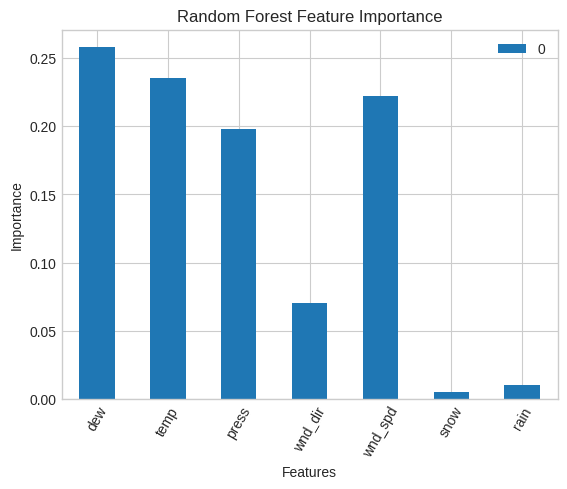

In [ ]:
feature_importance.plot(kind='bar')
plt.title('Random Forest Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=60)
#plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
plt.show()


### Usando Mutual Information

In [ ]:
# Divide los datos en características (X) y la variable objetivo (y)
x = dfNorm.drop('pollution', axis=1)  # Eliminar la columna 'pollution' para obtener las características
y = dfNorm['pollution']  # Variable objetivo

In [ ]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import SelectKBest
np.random.seed(42)


fs_num = SelectKBest(score_func=mutual_info_regression, k='all')


fs_num.fit(x, y)


feature_importance = pd.DataFrame({'Feature': fs_num.get_feature_names_out().tolist(),
                      'Score': fs_num.scores_.tolist()})

feature_importance = feature_importance.sort_values(by='Score', ascending=False)

print(feature_importance)


   Feature     Score
0      dew  0.153394
4  wnd_spd  0.121056
3  wnd_dir  0.108535
2    press  0.072408
1     temp  0.049977
6     rain  0.009615
5     snow  0.000000


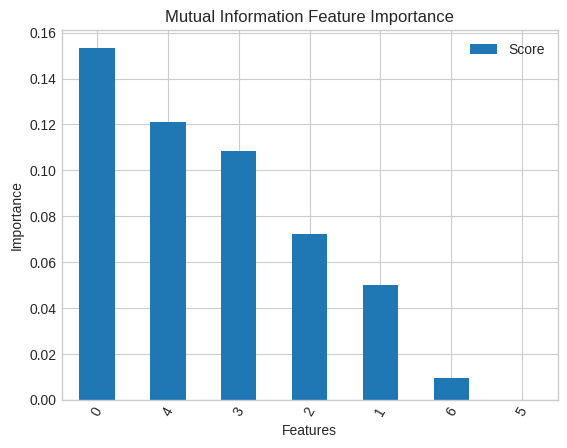

In [ ]:
feature_importance.plot(kind='bar')
plt.title('Mutual Information Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=60)
#plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
plt.show()

Es así como se puede ver que, en general, las variables más relevantes para el análisis son todas, a excepción de "snow" y "rain", por lo tanto estas últimas se descartan.

In [ ]:
originalFinal = df.drop(['snow', 'rain'], axis=1)
originalFinal.to_csv('/content/drive/MyDrive/Tesis/Data/SNpollutionFinal.csv')

# Otros análisis


## Lags óptimos

Información mutua para pollution: [1.5886382555294594, 1.1423003001637682, 0.9093763493209579, 0.7464882158265782, 0.6379780635472496, 0.54908891700574, 0.4864600417209397, 0.42537845458662993, 0.37858980617811167, 0.34436803767484037, 0.3180591794932379, 0.2932211192200098, 0.2649297869001659, 0.2536361010326811, 0.24079054415982526, 0.22390564611608, 0.21455785036073305, 0.20255866639263953, 0.19816456478399136, 0.18392744507000103, 0.1756958593367255, 0.16499302031395047, 0.16231456307167935, 0.1487995333485399]


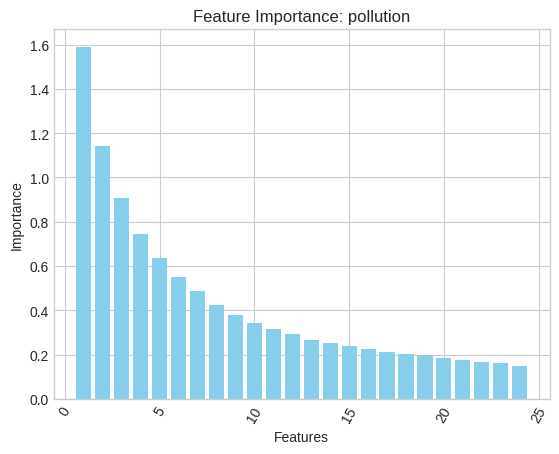

Información mutua para dew: [0.144128878686832, 0.1414200825528109, 0.13407174162037272, 0.13347893949677747, 0.12247507552115966, 0.11199382154763793, 0.10120010045979999, 0.10500340825992183, 0.09446844812391308, 0.0909583470186508, 0.08686500980775946, 0.08474601628805356, 0.08455325415461168, 0.08077955699683592, 0.083879064641045, 0.07431270270776746, 0.06739141254730185, 0.07287672339733486, 0.07474000290651883, 0.07101804194946659, 0.07450832184224332, 0.06898903544450263, 0.06729107472199658, 0.06601652234742961]


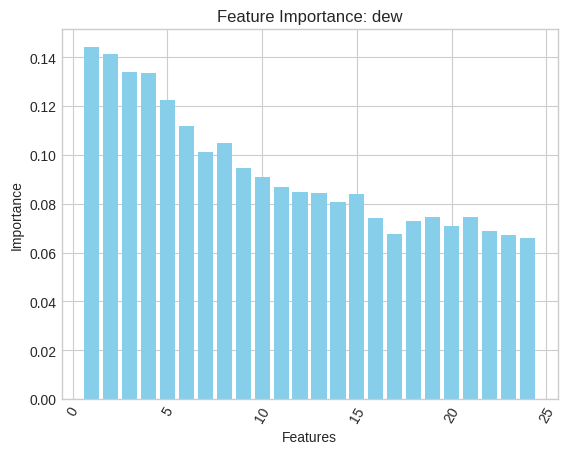

Información mutua para temp: [0.06011571904864166, 0.05191290987896924, 0.056623528199803985, 0.05514836847074278, 0.05739903577046679, 0.06420756107594272, 0.058632357490918, 0.05885675359742404, 0.06455620716217414, 0.05739055066112808, 0.06555225124109842, 0.055479941704714264, 0.05596963507529118, 0.05626056526129375, 0.05219740760082647, 0.05014848763659607, 0.050238558633124875, 0.04622860857202049, 0.047060852505211415, 0.0488060129356338, 0.04895604234926765, 0.05328464523088705, 0.047461494474709376, 0.04614786646896718]


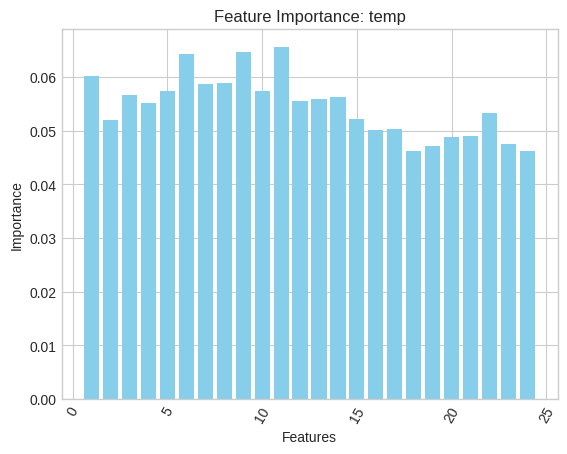

Información mutua para press: [0.06013773301551506, 0.07281267495322385, 0.06562736989458706, 0.0691276562084493, 0.06612075970283104, 0.06010047484879699, 0.05682711808206964, 0.05913405342054112, 0.05406244516934233, 0.04932778511456437, 0.049779620550371106, 0.05380728124682843, 0.0517807696108008, 0.05335739549448526, 0.04469210456108108, 0.05033539354663752, 0.05364259142094863, 0.054871856599834956, 0.04480245916014702, 0.041481342877778715, 0.0456380818565032, 0.048888015154378905, 0.045482157031123016, 0.0526551385472116]


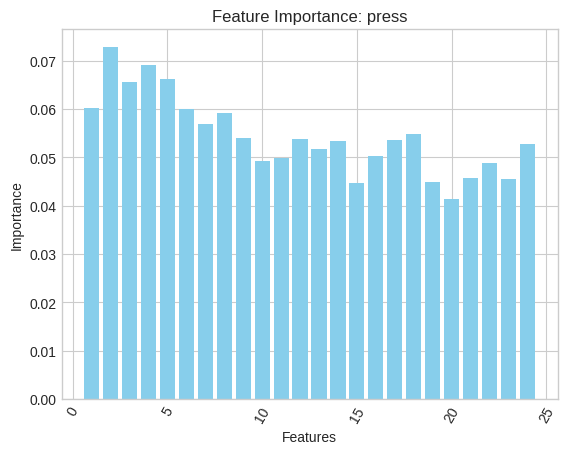

Información mutua para wnd_dir: [0.12331972239286815, 0.13900268496166568, 0.14486119905182493, 0.14687347590846977, 0.15192437539366477, 0.1422662831263941, 0.13721930672486415, 0.13438307850859443, 0.12378714967792037, 0.11712241973276427, 0.10024728620946632, 0.09261905268360549, 0.08028030822627441, 0.07580933884170582, 0.07429709536133888, 0.062183133807064195, 0.04957647327053927, 0.05405288289531818, 0.04587069148667178, 0.050569956340787314, 0.03791333788906748, 0.03861257911829785, 0.03780779850591287, 0.03469163628205152]


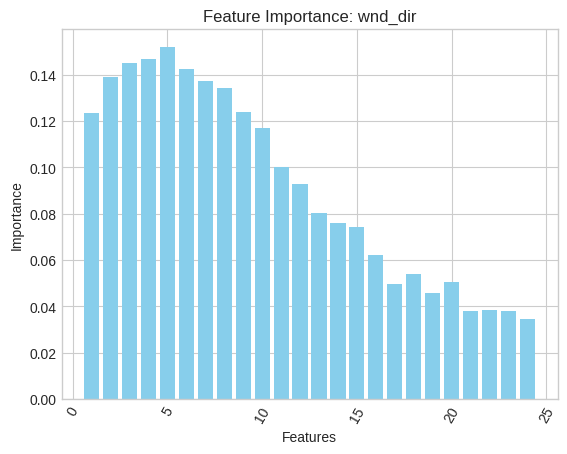

Información mutua para wnd_spd: [0.12739897942761136, 0.12275818915564152, 0.1250066010329256, 0.1156603668133398, 0.1092113065181346, 0.10588288695271064, 0.09096267087775889, 0.0828165073676903, 0.07201359067073554, 0.07642935054744449, 0.06727662916222865, 0.06391041788117668, 0.05296296173408788, 0.057460946348849795, 0.05363165857609786, 0.05055944105043597, 0.04721332588686167, 0.041526101043889874, 0.04013045862798936, 0.04282830903754764, 0.04310821158168299, 0.03825265150920476, 0.04146479691250349, 0.03839400268730131]


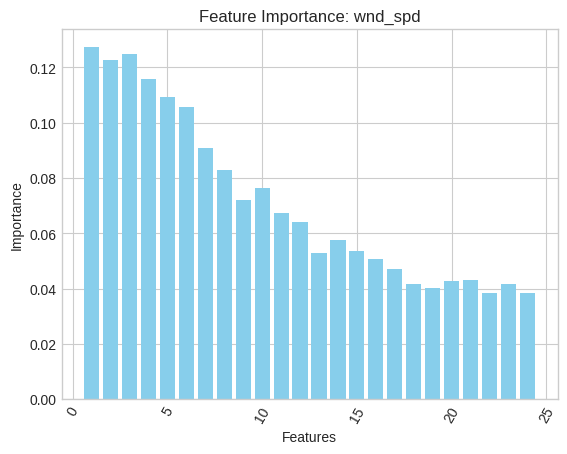

Lags óptimos encontrados para cada columna:
{'pollution': 1, 'dew': 1, 'temp': 11, 'press': 2, 'wnd_dir': 5, 'wnd_spd': 1}


In [ ]:
from sklearn.feature_selection import mutual_info_regression
import numpy as np
import pandas as pd
from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
np.random.seed(42)


data = final.copy()


num_lags = 24  # Número máximo de lags a considerar

ejeX = list(range(1, num_lags+1))


for i in range(1, num_lags + 1):
    for col in final.columns:
        data[f'{col}_lag_{i}'] = final[col].shift(i)


lag_optimos = {}


def calculate_mutual_info(X, y):
    mi = mutual_info_regression(X, y)
    return mi

# Iterar sobre cada columna (cada serie temporal de lag)
for col in final.columns:
    mutual_infos = []
    for i in range(1, num_lags + 1):
        # Extraer la característica de lag y la serie objetivo

        data2 = data.dropna(subset=[f'{col}_lag_{i}'])

        X = data2[[f'{col}_lag_{i}']]
        y = data2['pollution'] 

        # Calcular la información mutua
        mi = calculate_mutual_info(X, y)
        mutual_infos.append(mi[0])  # Guardar el valor de información mutua

    print(f"Información mutua para {col}: {mutual_infos}")

    plt.bar(ejeX, mutual_infos, color='skyblue')
    plt.title(f'Feature Importance: {col}')
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.xticks(rotation=60)
    #plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
    plt.show()


    # Encontrar el lag con la mayor importancia
    lag_optimo = np.argmax(mutual_infos) + 1
    lag_optimos[col] = lag_optimo

print("Lags óptimos encontrados para cada columna:")
print(lag_optimos)


## Se crean conjuntos de datos

# Otros códigos

A continuación se estudia la estacionalidad de la variable a predecir mediante el test Augmented Dickey-Fuller (ADF). De acuerdo a este test, todas las series de tiempo en el dataset son estacionarias.

In [ ]:
def dfuller(name, data):
  resultado_adf = adfuller(data[name])
  print("Variable: ", name)
  # Imprime el resultado
  print('Estadística ADF:', resultado_adf[0])
  print('Valor p:', resultado_adf[1])
  print("Cantidad de observaciones utilizadas: ", resultado_adf[2])
  print('Valores críticos:')
  for key, value in resultado_adf[4].items():
      print('\t%s: %.3f' % (key, value))



In [ ]:
for name in df:
  dfuller(name, df)

Variable:  pollution
Estadística ADF: -21.347130264676284
Valor p: 0.0
Cantidad de observaciones utilizadas:  54
Valores críticos:
	1%: -3.430
	5%: -2.862
	10%: -2.567
Variable:  dew
Estadística ADF: -6.086701518331369
Valor p: 1.0601628284120799e-07
Cantidad de observaciones utilizadas:  55
Valores críticos:
	1%: -3.430
	5%: -2.862
	10%: -2.567
Variable:  temp
Estadística ADF: -3.8735275608584687
Valor p: 0.0022385419293692223
Cantidad de observaciones utilizadas:  49
Valores críticos:
	1%: -3.430
	5%: -2.862
	10%: -2.567
Variable:  press
Estadística ADF: -7.380073775883129
Valor p: 8.518361949892657e-11
Cantidad de observaciones utilizadas:  55
Valores críticos:
	1%: -3.430
	5%: -2.862
	10%: -2.567
Variable:  wnd_dir
Estadística ADF: -19.775664887790793
Valor p: 0.0
Cantidad de observaciones utilizadas:  55
Valores críticos:
	1%: -3.430
	5%: -2.862
	10%: -2.567
Variable:  wnd_spd
Estadística ADF: -33.923697114110375
Valor p: 0.0
Cantidad de observaciones utilizadas:  5
Valores crític

Para confirmar, se imprimen las gráficas de la función de autocorrelación de cada variable. Al haber descensos consistentes y lentos, no haber convergencia en algún punto y la existencia de un componente temporal, pareciese indicar que las series probablemente no son estacionarias. De igual manera, la presencia de repetición en ciertos patrones pareciese indicar que existe estacionalidad en algunas series.

In [ ]:
def acf(name, data):
  plot_acf(data[name], lags=50)
  plt.xlabel('Lag')
  plt.ylabel('Autocorrelation')
  plt.title('Gráfico de ACF para {}'.format(name))
  plt.show()

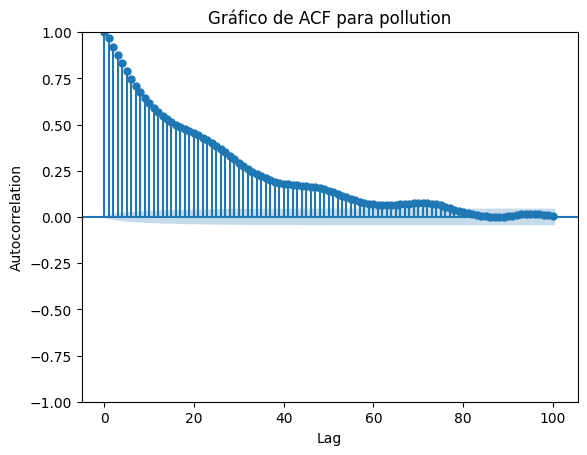

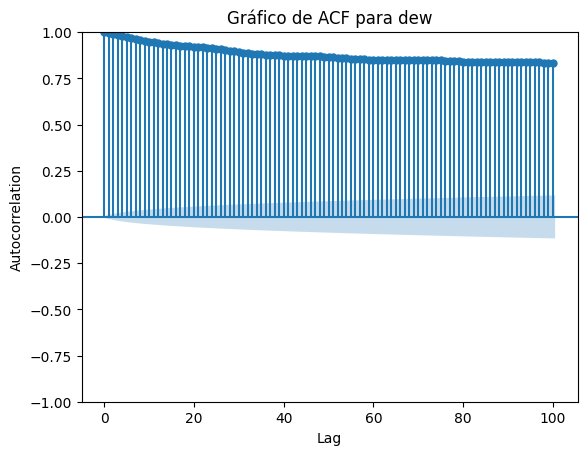

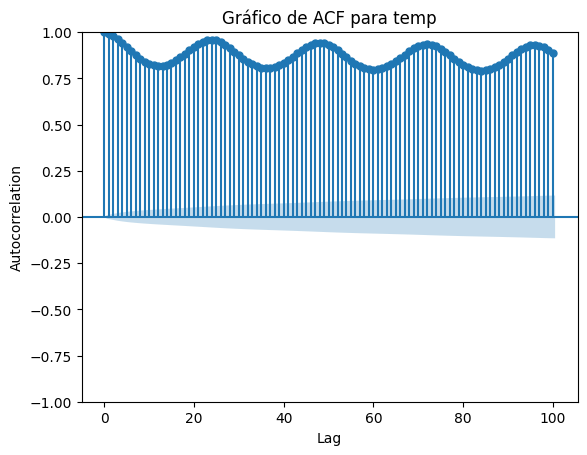

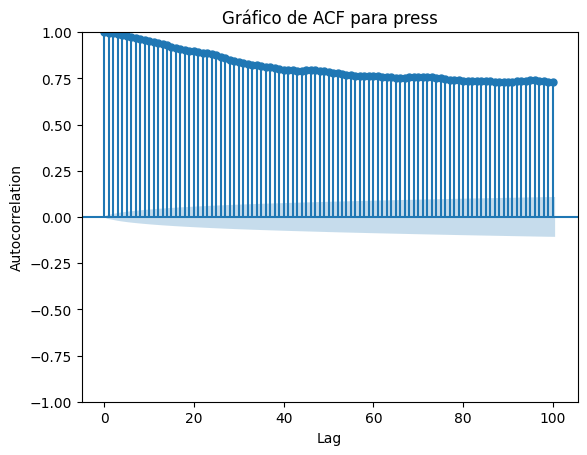

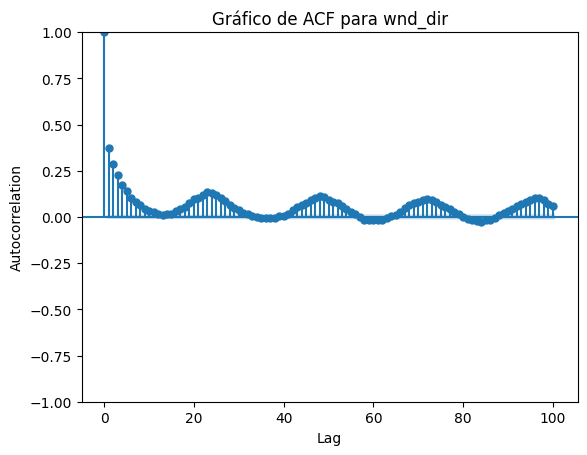

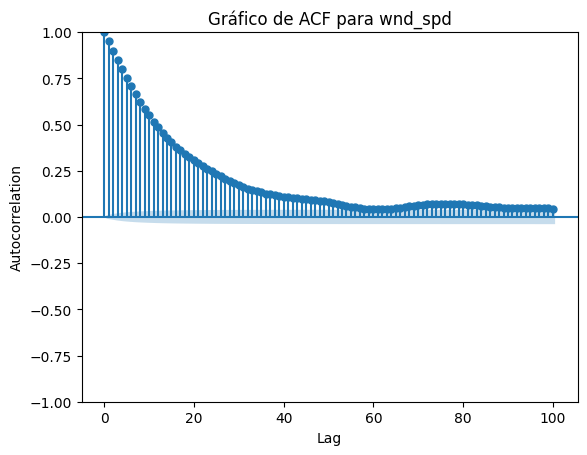

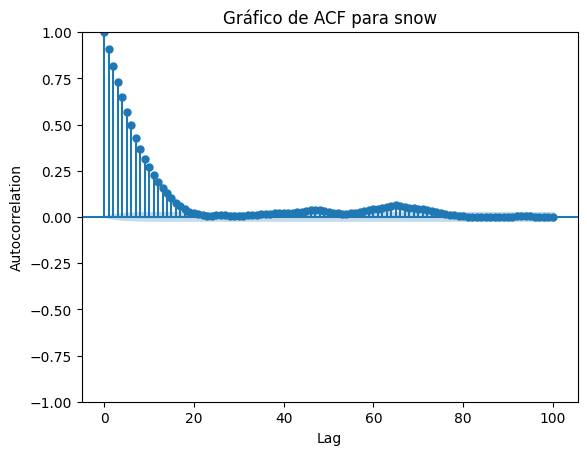

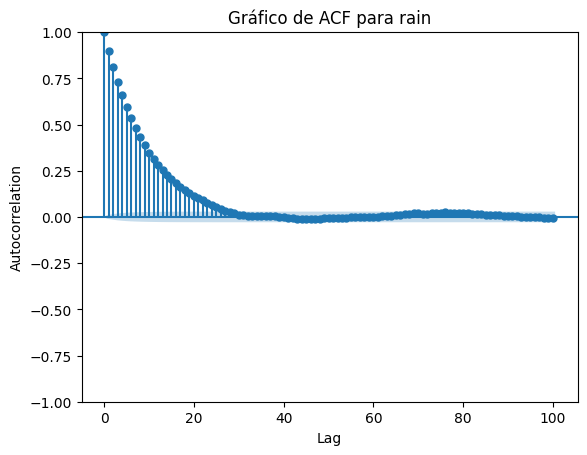

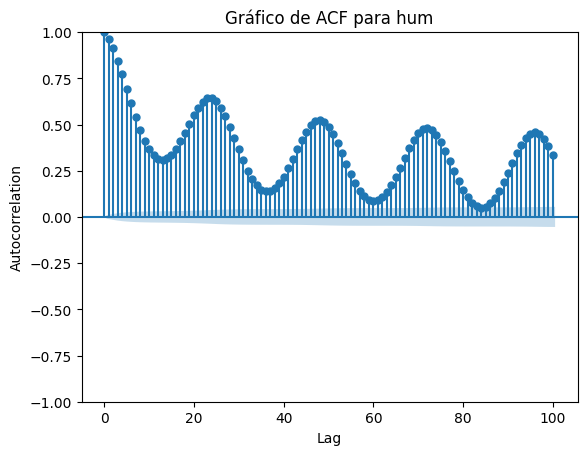

In [ ]:
for name in df:
  acf(name, df)

A modo de investigar la inconsistencia anterior, se resamplea la serie a un periodo de 24 hrs, promediando los valores en sí, para así revisar si los gráficos ACF cambian.

Cada 24 Hrs

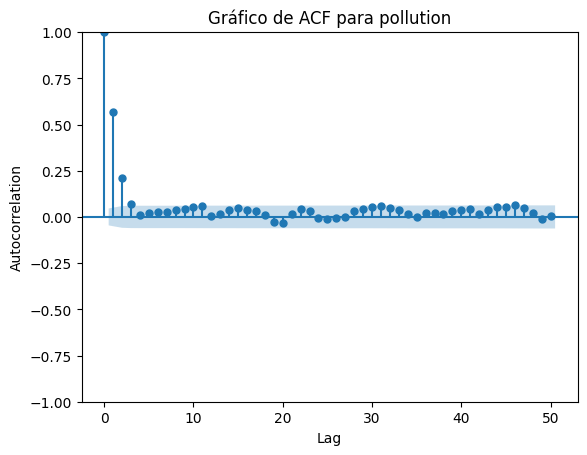

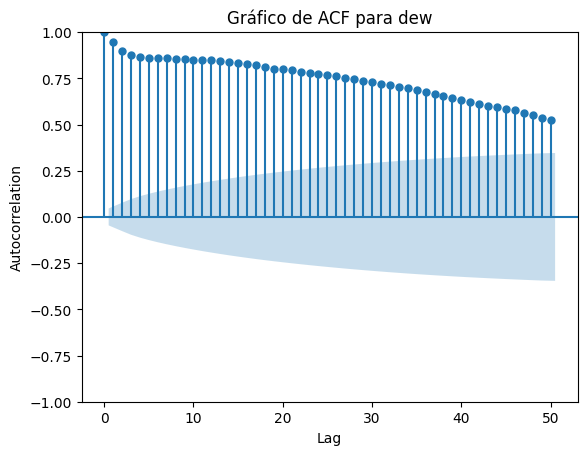

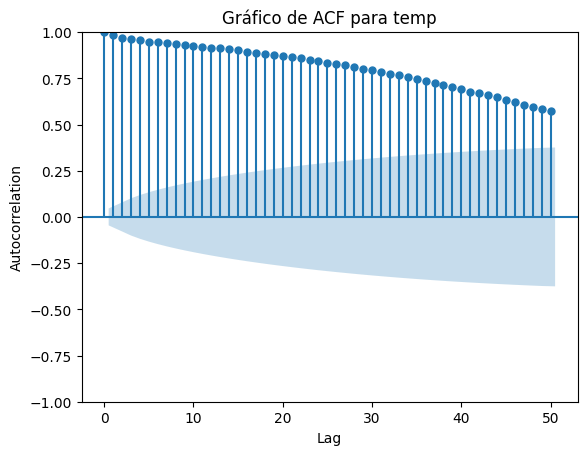

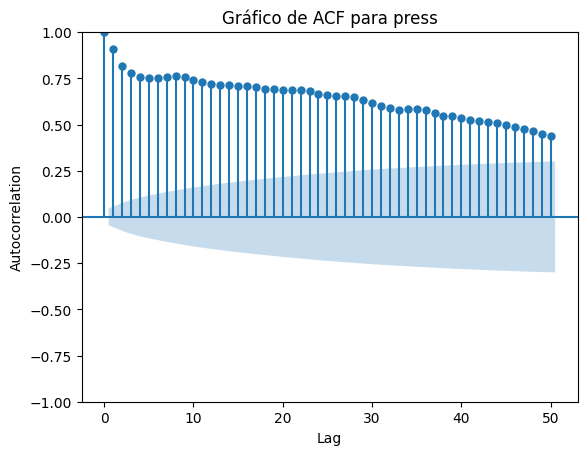

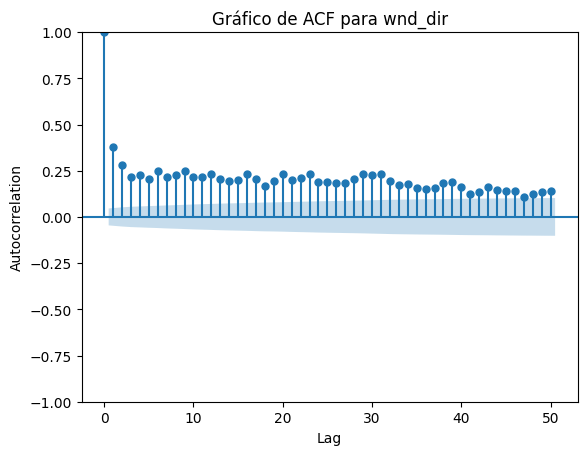

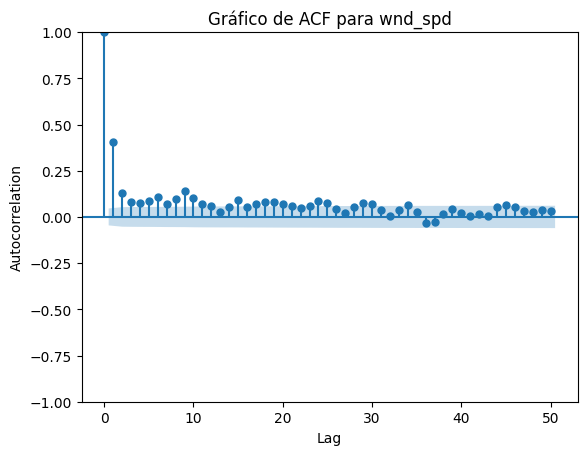

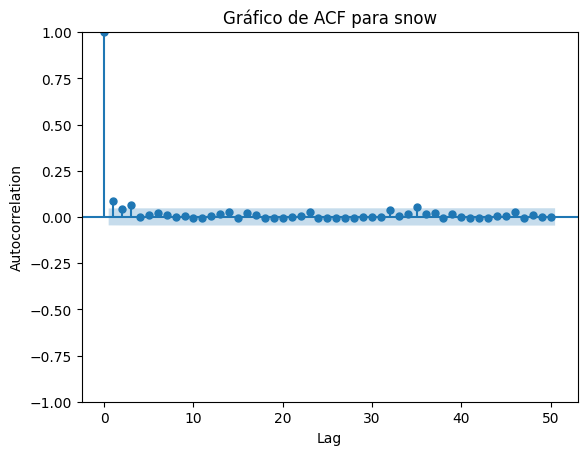

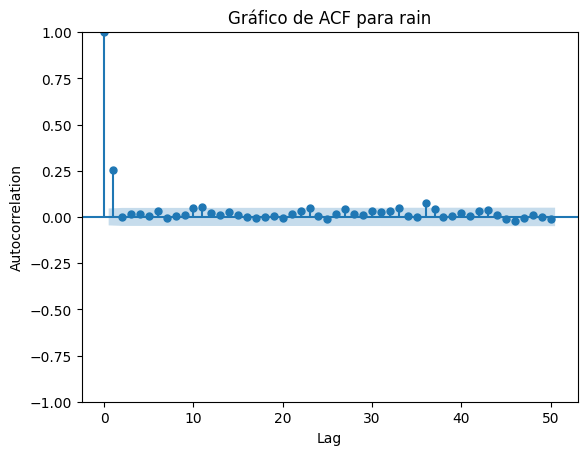

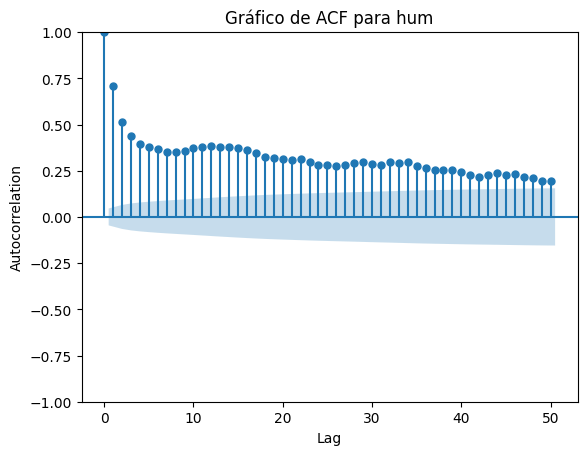

In [ ]:
data_resampled = df.resample('24H').mean()
for name in data_resampled:
  acf(name, data_resampled)

Cada Mes

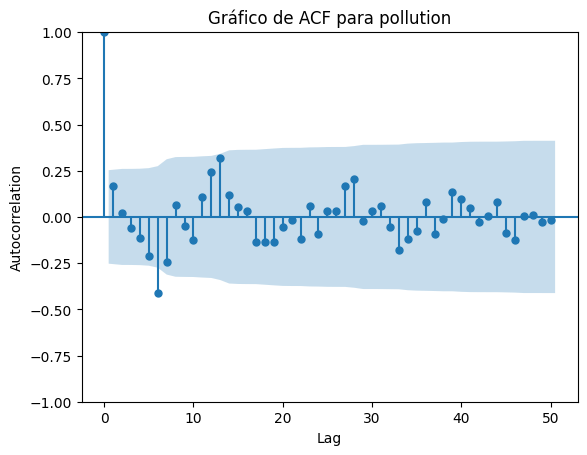

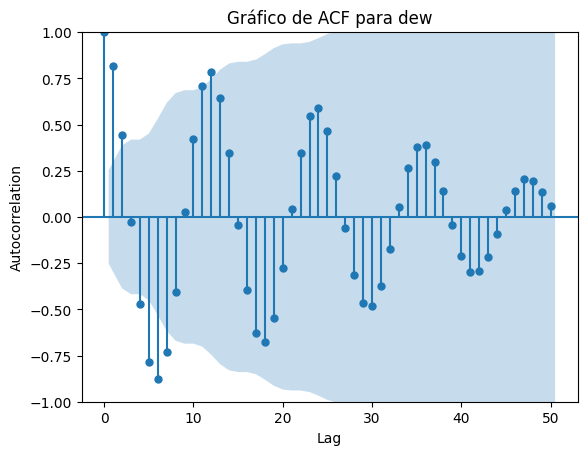

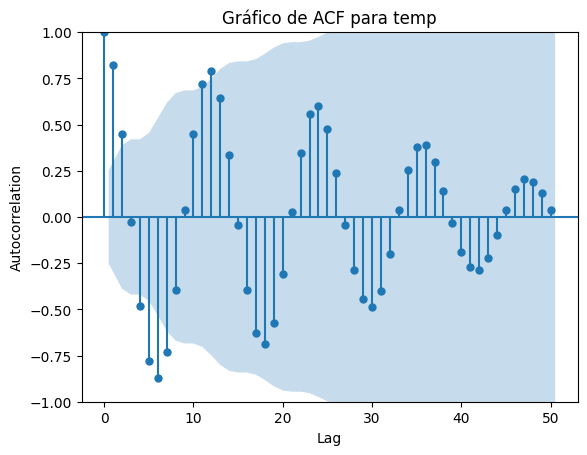

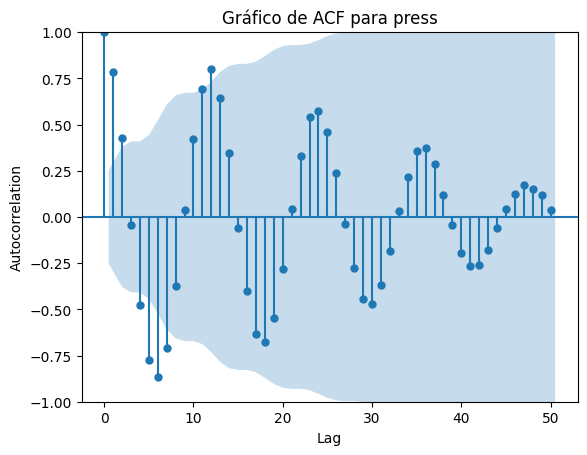

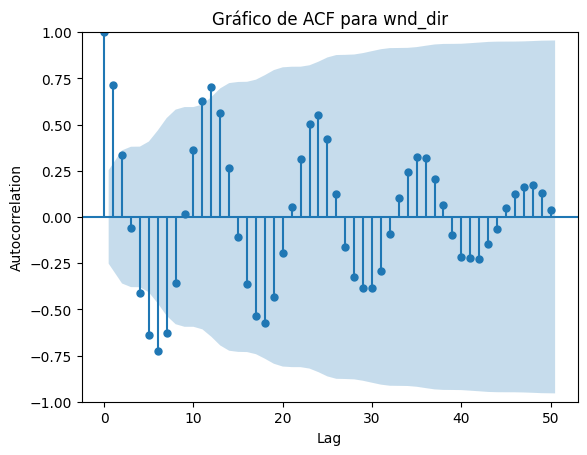

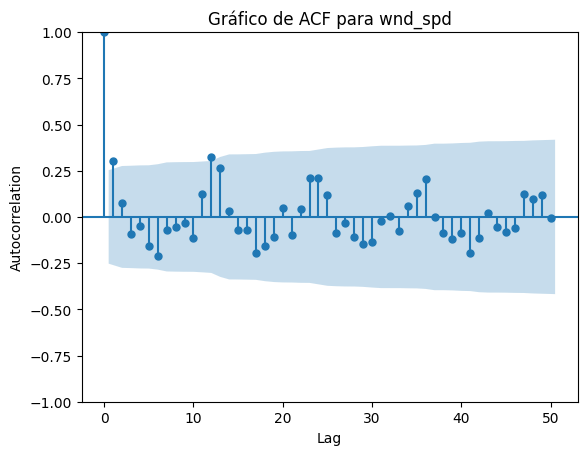

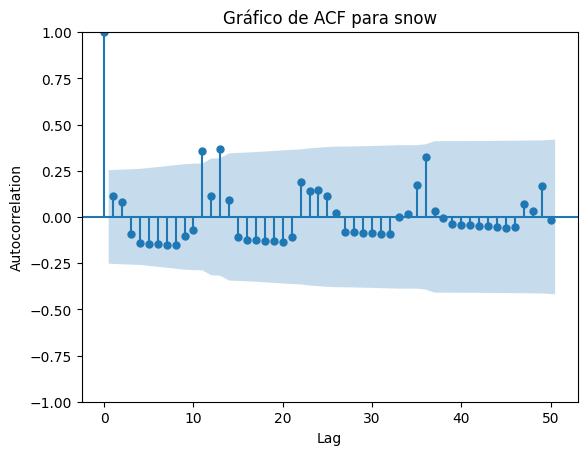

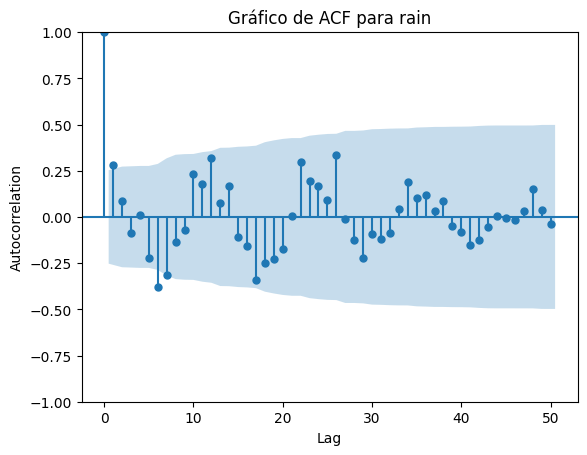

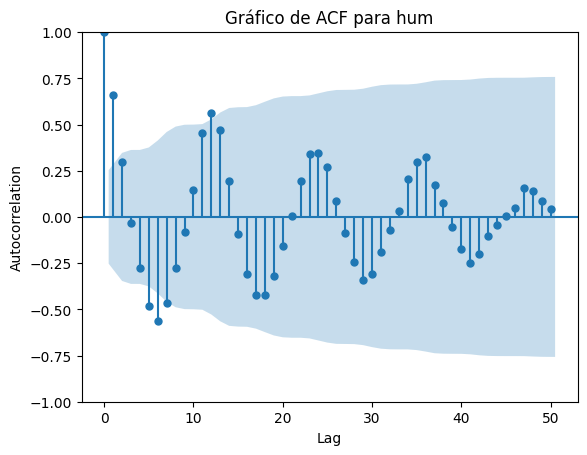

In [ ]:
data_resampled2 = df.resample('M').mean()
for name in data_resampled2:
  acf(name, data_resampled2)

De los gráficos anteriores se puede observar que, si bien ahora el decaimiento es mucho más rápido, aún pareciesen haber componentes que indican la presencia de estacionalidad.

Para comprender de mejor forma el análisis, se realiza una descomposición de las variables originales, resampled (24h) y resampled (1M). Luego de imprimir los gráficos, es posible concluir lo siguiente:



*   En un inicio, al descomponer las series en su rango de tiempo original, es decir cada hora, no hay estacionalidad notoria directamente, solo un "bloque" solido en donde debiese estar el gráfico de estacionalidad. Al hacer resampleo de los datos, dicho bloque comienza a mostrar cierto grado de estacionalidad, llegando a que en el gráfico para resampleo cada mes se muestre la existencia de estacionalidad para todas las variables.

*   En términos de tendencia, con sampleos pequeños (H y 24H), las variables que parecen mostrar una tendencia clara son dew, temp, press y hum. Sin embargo, al momento de aumentar el rango del sampleo (M), estas tendencias ya no son claras.

*   A pesar de esto, para sampleos de 24H y M, dew y temp ahora presentan valores p de la prueba ADF mayores a niveles de significancia comunes, pudiendo siginifacar que dichas series no son estacionarias.
*   Lo mismo anterior ocurre para hum en sampleos M y press en sampleos 24H.


En base a los últimos 2 puntos anteriores, es posible ver que, al aumentar el rango de sampleo de las observaciones, aquellas que tenían una tendencia clara desde el inicio pasaron de ser consideradas como estacionarias a no estacionarias de acuerdo a la prueba de ADF.



In [ ]:
def descomponer(name, data):
  decompose = seasonal_decompose(data[name], model='additive')

  decompose.plot()
  plt.subplots_adjust(right=1.25)
  plt.show()

#decompose.seasonal["2010-01"].plot()
#plt.subplots_adjust(right=1.25)

#plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))

#plt.show()



In [ ]:
print("Descomposición para observaciones cada hora")

for name in df:
  descomponer(name, df)

print("Descomposición para observaciones cada 24 horas")
for name in data_resampled:
  descomponer(name, data_resampled)
  dfuller(name, data_resampled)
print("Descomposición para observaciones cada mes")
for name in data_resampled2:
  descomponer(name, data_resampled2)
  dfuller(name, data_resampled2)

Output hidden; open in https://colab.research.google.com to view.

Se empieza a jugar con el parámetro period de seasonal_decompose para la variable pollution con el sampleo original. Todas muestran estacionalidad.

Con periodo de 720 (horas en un mes)

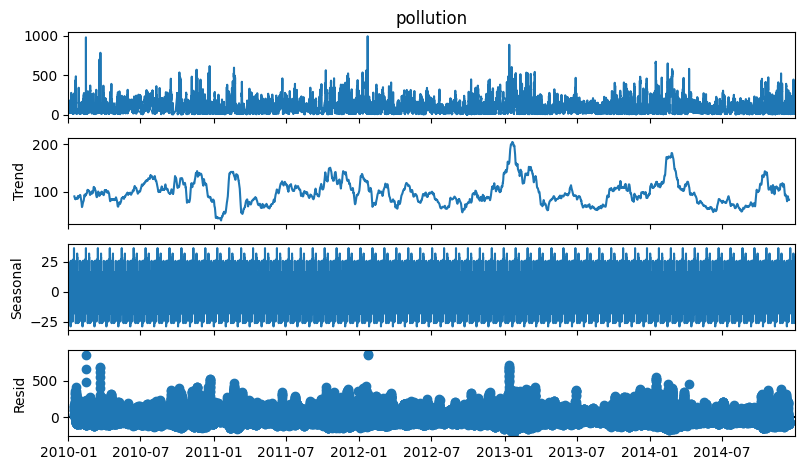

In [ ]:
decompose = seasonal_decompose(df['pollution'],model='additive', period=720)
decompose.plot()
plt.subplots_adjust(right=1.25)
plt.show()




Con periodo de 4320 (horas en 6 meses)

> Agregar bloque entrecomillado



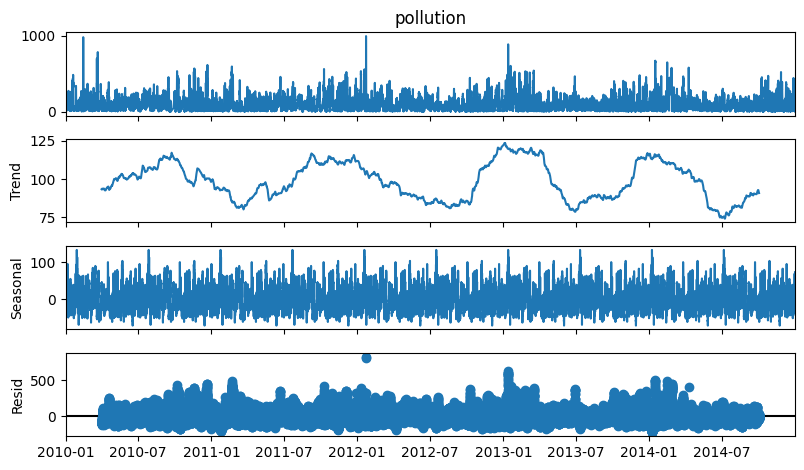

In [ ]:
decompose = seasonal_decompose(df['pollution'],model='additive', period=4320)
decompose.plot()
plt.subplots_adjust(right=1.25)
plt.show()




Con periodo de 8640 (horas en un año)

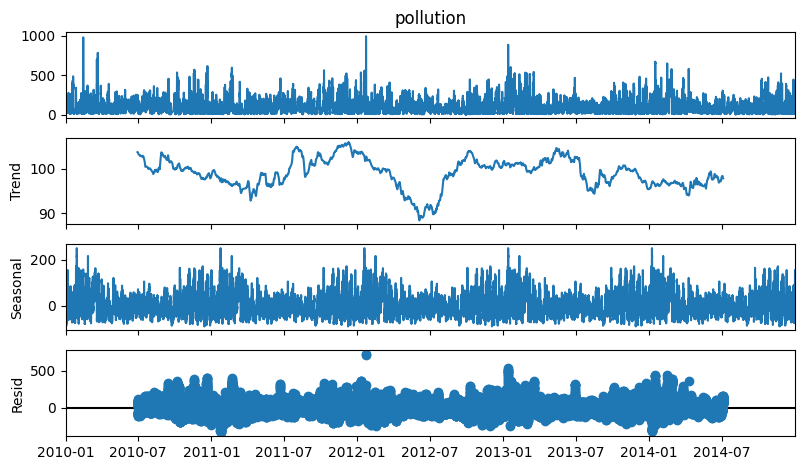

In [ ]:
decompose = seasonal_decompose(df['pollution'],model='additive', period=8640)
decompose.plot()
plt.subplots_adjust(right=1.25)
plt.show()




In [ ]:
# Extraer la serie de tiempo de tus datos
serie_tiempo = df['press']

# Realizar la prueba de normalidad de Shapiro-Wilk
shapiro_test_statistic, shapiro_p_value = stats.shapiro(serie_tiempo)
print("Prueba de Shapiro-Wilk:")
print("Estadística de prueba:", shapiro_test_statistic)
print("Valor p:", shapiro_p_value)

# Realizar la prueba de normalidad de Kolmogorov-Smirnov
kstest_statistic, kstest_p_value = stats.kstest(serie_tiempo, 'norm')
print("\nPrueba de Kolmogorov-Smirnov:")
print("Estadística de prueba:", kstest_statistic)
print("Valor p:", kstest_p_value)


Prueba de Shapiro-Wilk:
Estadística de prueba: 0.9831407070159912
Valor p: 0.0

Prueba de Kolmogorov-Smirnov:
Estadística de prueba: 1.0
Valor p: 0.0


/usr/local/lib/python3.10/dist-packages/scipy/stats/_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
